<a href="https://colab.research.google.com/github/DaviMatoso/MachineLearning/blob/main/Modelo_Comportamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparação do ambiente

In [ ]:
#Instalar bibliotecas necessárias (descomente se necessário)
!pip install seaborn plotly missingno category_encoders

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno
import category_encoders as ce

from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from statsmodels.graphics.mosaicplot import mosaic


warnings.filterwarnings('ignore')

**Para a modelagem**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
url = "/content/credito_aplicacao_clientes_final.csv"
url2 = "/content/credito_comportamental_pedidos_final.csv"
df = pd.read_csv(url)
df2 = pd.read_csv(url2)

In [ ]:
df_uniao = df.join(df2.set_index('id_cliente'), on='id_cliente', how='inner')

#### Pequena analise das dimensões

In [ ]:
print(f"Dimensões: {df_uniao.shape[0]} linhas × {df_uniao.shape[1]} colunas")

Dimensões: 1977 linhas × 23 colunas


In [ ]:
print("Tipos de dados")
print(df_uniao.dtypes)

Tipos de dados
id_cliente                           int64
uf                                  object
municipio                           object
segmento_cliente                    object
natureza_juridica                   object
fonte_cliente                       object
cnae_codigo                         object
capital_social                      object
idade_cnpj                          object
serasa_contagem_negativacoes       float64
serasa_contagem_protestos          float64
serasa_credores                     object
serasa_socio_tem_negativacao       float64
ifood_contagem_avaliacoes           object
ifood_faixa_preco                   object
google_maps_avaliacao               object
google_maps_contagem_avaliacoes     object
google_maps_tem_website            float64
inadimplente                       float64
id_pedido                            int64
valor                               object
atraso                              object
data_entrega                        obj

In [ ]:
print("Vizualização da tabela")
display(df_uniao.head(5))

Vizualização da tabela


,id_cliente,uf,municipio,segmento_cliente,natureza_juridica,fonte_cliente,cnae_codigo,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_credores,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,inadimplente,id_pedido,valor,atraso,data_entrega
3,1003899664289,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.74-5-45,"(2000, 3000]","(900, 1150]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1056993226169,"(0, 500]","(6, 10]",2023-05-22
3,1003899664289,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.74-5-45,"(2000, 3000]","(900, 1150]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,2165209463214,"(0, 500]","(6, 10]",2023-04-04
3,1003899664289,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.74-5-45,"(2000, 3000]","(900, 1150]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,7435882525637,"(0, 500]","(2, 4]",2023-03-10
6,1006479800959,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.77-2-39,"(1500, 2000]","(900, 1150]",0.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0.0,1815848889570,"(0, 500]","(0, 2]",2024-01-23
6,1006479800959,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.77-2-39,"(1500, 2000]","(900, 1150]",0.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0.0,6774027615605,"(0, 500]","(-100, 0]",2023-11-23


In [ ]:
print("\n ESTATÍSTICAS DESCRITIVAS:")
display(df_uniao.describe())


 ESTATÍSTICAS DESCRITIVAS:


,id_cliente,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_socio_tem_negativacao,google_maps_tem_website,inadimplente,id_pedido
count,1.977000e+03,1977.000000,1977.000000,1977.000000,195.0,1977.000000,1.977000e+03
mean,4.336217e+12,0.911482,0.201315,0.466363,1.0,0.202833,5.345685e+12
std,1.864467e+12,3.031006,1.168903,0.498993,0.0,0.402211,2.621358e+12
min,1.003900e+12,0.000000,0.000000,0.000000,1.0,0.000000,1.001468e+12
25%,2.926608e+12,0.000000,0.000000,0.000000,1.0,0.000000,2.960214e+12
50%,4.303790e+12,0.000000,0.000000,0.000000,1.0,0.000000,5.281486e+12
75%,5.853842e+12,0.000000,0.000000,1.000000,1.0,0.000000,7.612467e+12
max,7.709813e+12,37.000000,20.000000,1.000000,1.0,1.000000,9.999664e+12


In [ ]:
target_var = 'inadimplente'

# Tratamento de Nulos


Análise de nulos:


,0
id_cliente,0
uf,0
municipio,0
segmento_cliente,0
natureza_juridica,0
fonte_cliente,0
cnae_codigo,0
capital_social,0
idade_cnpj,0
serasa_contagem_negativacoes,0


<Axes: >

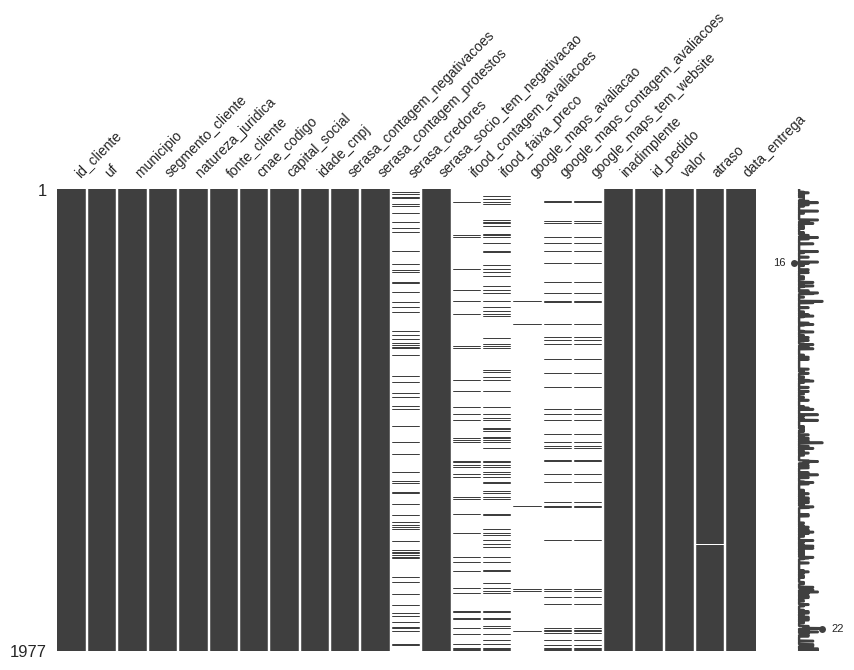

In [ ]:
#Análise de valores faltantes
print("Análise de nulos:")
display(df_uniao.isna().sum())

#visualização
msno.matrix(df_uniao, figsize=(10, 6), fontsize=10)

In [ ]:
#google maps
cols = [
    'google_maps_avaliacao',
    'google_maps_contagem_avaliacoes',
    'google_maps_tem_website'
]

mask_sem_gmaps = df_uniao[cols].isna().all(axis=1)

print(mask_sem_gmaps.sum())

1782


In [ ]:
df_uniao['tem_google_maps'] = np.where(mask_sem_gmaps, 0, 1)

In [ ]:
#ifood
cols_ifood = [
   'ifood_contagem_avaliacoes',
   'ifood_faixa_preco'
]

mask_sem_ifood = df_uniao[cols_ifood].isna().all(axis=1)

print(mask_sem_ifood.sum())

1638


In [ ]:
df_uniao['tem_ifood'] = np.where(mask_sem_ifood, 0, 1)

In [ ]:
#serasa credores ( No caso do cliente não dever para outra empresa, o campo é nulo.)
df_uniao['serasa_credores'] = df_uniao['serasa_credores'].fillna("Sem credor")

In [ ]:
df3 = df_uniao.drop(columns = ['ifood_faixa_preco','ifood_contagem_avaliacoes','google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'google_maps_tem_website'])

Análise de nulos:


,0
id_cliente,0
uf,0
municipio,0
segmento_cliente,0
natureza_juridica,0
fonte_cliente,0
cnae_codigo,0
capital_social,0
idade_cnpj,0
serasa_contagem_negativacoes,0


<Axes: >

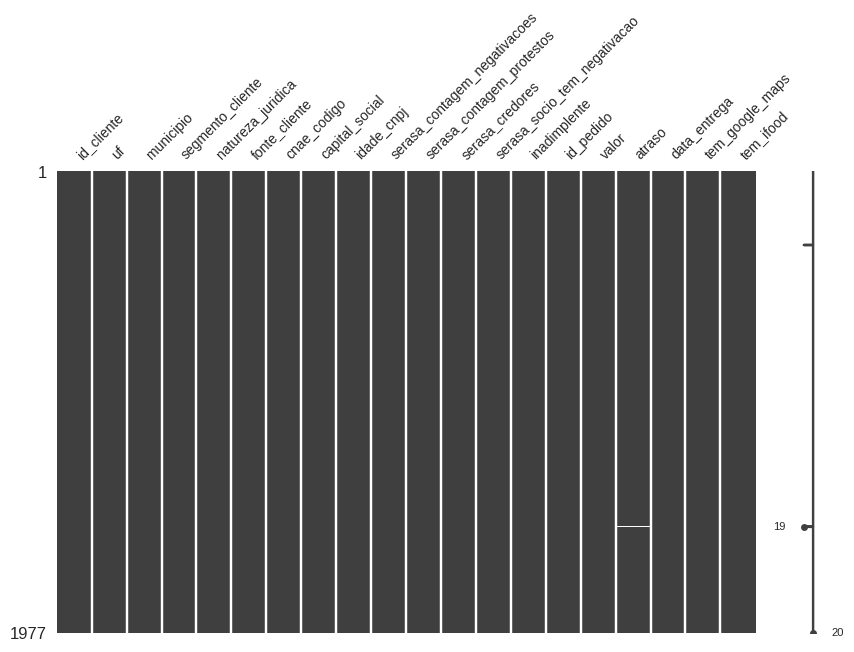

In [ ]:
#Análise de valores faltantes
print("Análise de nulos:")
display(df3.isna().sum())

#visualização
msno.matrix(df3, figsize=(10, 6), fontsize=10)

# Análise Univariada

In [ ]:
# Separar variáveis por tipo
numeric_vars = df3.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df3.select_dtypes(include=['object']).columns.tolist()


In [ ]:
#Visualização e retirada de ID da lista de variáveis numéricas para EDA
numerico = [col for col in numeric_vars if col != 'id_cliente']

print(f"Variáveis numéricas: {numerico}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'serasa_socio_tem_negativacao', 'inadimplente', 'id_pedido', 'tem_google_maps', 'tem_ifood']
Variáveis categóricas: ['uf', 'municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'cnae_codigo', 'capital_social', 'idade_cnpj', 'serasa_credores', 'valor', 'atraso', 'data_entrega']


## Categóricas e intervalos

In [ ]:
# Análise de frequências
for var in categorical_vars:
    if var in df3.columns:
        print(f"\n {var.upper()}:")
        freq_table = df3[var].value_counts()
        freq_percent = df3[var].value_counts(normalize=True) * 100

        freq_df3 = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df3.head(10))

        # Medida de concentração
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


 UF:
    Frequência  Percentual
uf                        
CE        1977       100.0
  Entropia: 0.000

 MUNICIPIO:
           Frequência  Percentual
municipio                        
FORTALEZA        1268   64.137582
CAUCAIA           262   13.252403
EUSEBIO            65    3.287810
MARACANAU          57    2.883156
ARACATI            45    2.276176
PACAJUS            39    1.972686
AQUIRAZ            36    1.820941
BEBERIBE           36    1.820941
ITAITINGA          24    1.213961
HORIZONTE          21    1.062215
  Entropia: 1.506

 SEGMENTO_CLIENTE:
                  Frequência  Percentual
segmento_cliente                        
Segmento 20              440   22.255943
Segmento 18              308   15.579160
Segmento 15              233   11.785534
Segmento 16              220   11.127972
Segmento 10              183    9.256449
Segmento 19              144    7.283763
Segmento 5               124    6.272129
Segmento 3                62    3.136065
Segmento 11               

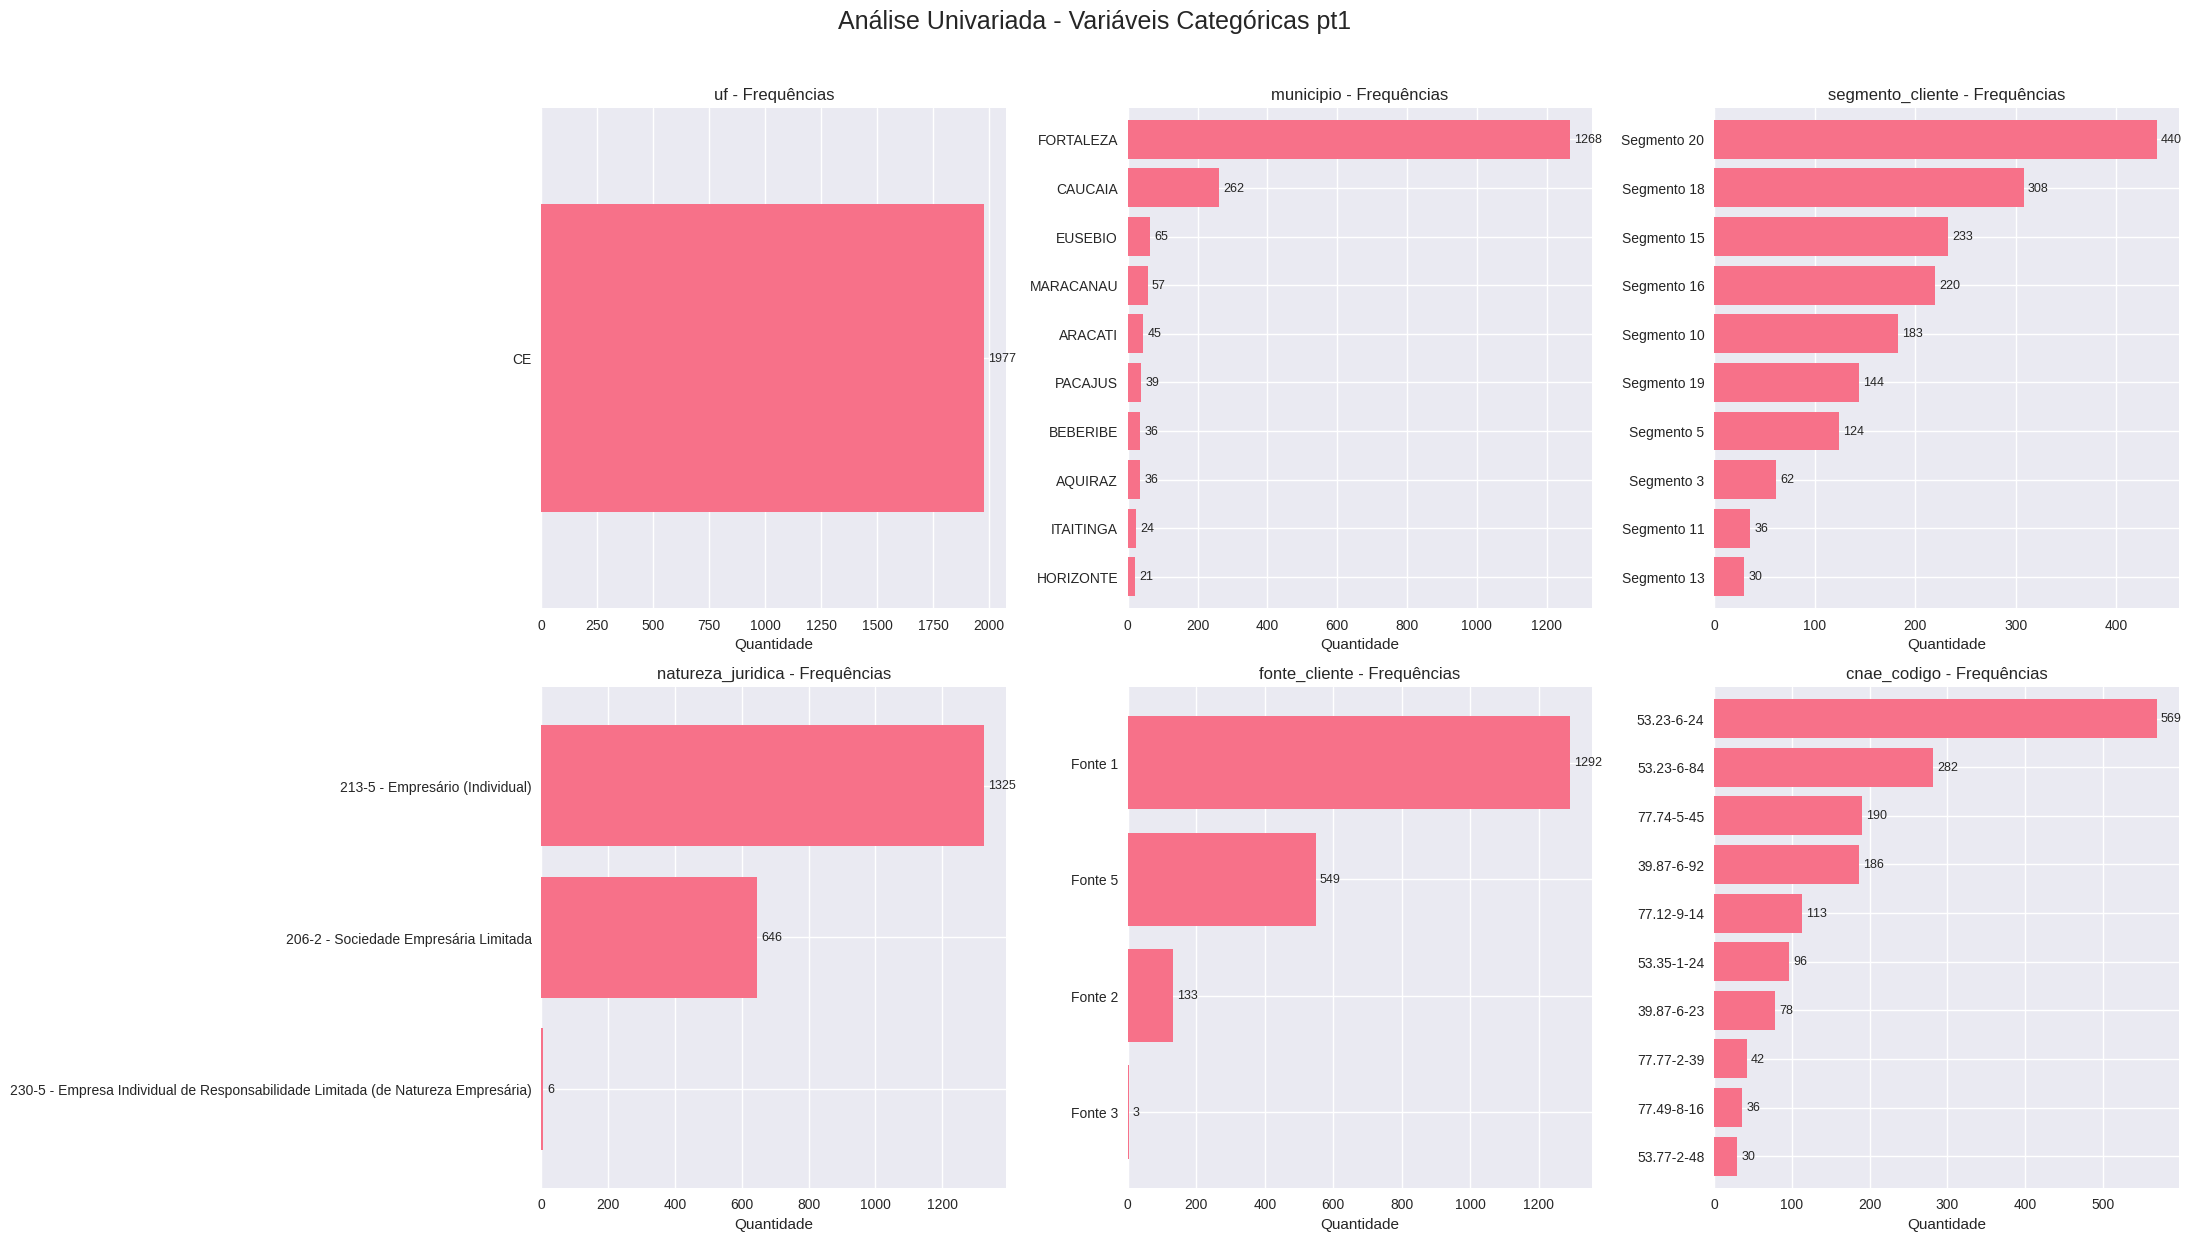

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    4,
    3,
    figsize=(22, 24)
)

fig.suptitle(
    'Análise Univariada - Variáveis Categóricas pt1',
    fontsize=18
)

axes = axes.flatten()

for i, var in enumerate(categorical_vars[:6]):

    if var in df3.columns:

        # Top 10 categorias mais frequentes
        value_counts = (
            df3[var]
            .value_counts()
            .head(10)
            .sort_values()
        )

        # Sempre gráfico horizontal
        value_counts.plot(
            kind='barh',
            ax=axes[i],
            width=0.8
        )

        axes[i].set_title(
            f'{var} - Frequências',
            fontsize=12
        )

        axes[i].set_xlabel('Quantidade')
        axes[i].set_ylabel('')

        # Coloca os valores ao lado das barras
        for container in axes[i].containers:
            axes[i].bar_label(
                container,
                padding=3,
                fontsize=9
            )

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

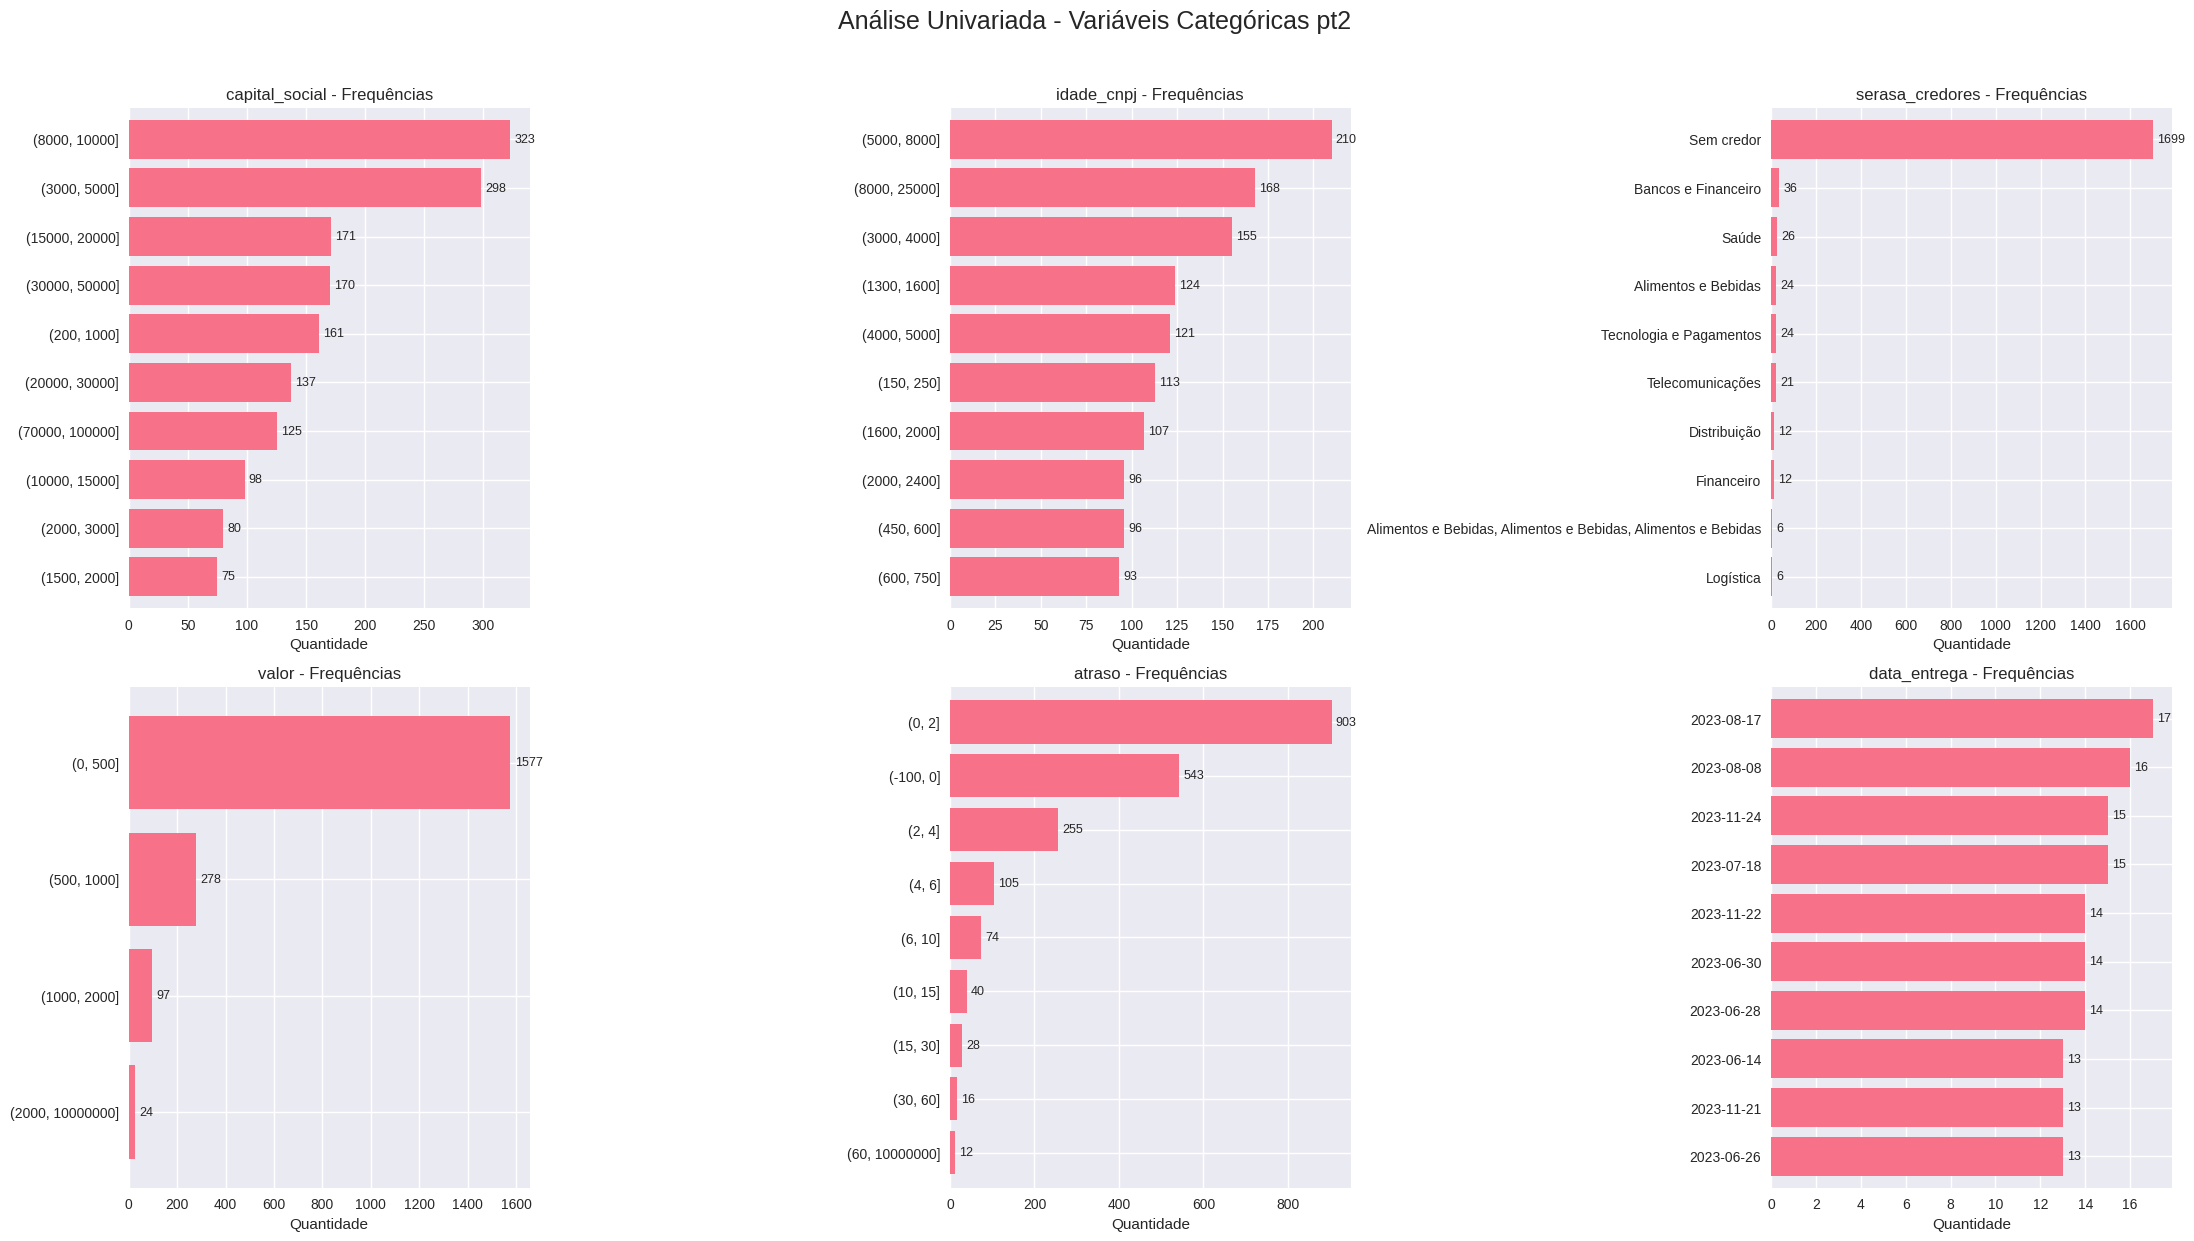

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    4,
    3,
    figsize=(22, 24)
)

fig.suptitle(
    'Análise Univariada - Variáveis Categóricas pt2',
    fontsize=18
)

axes = axes.flatten()

for i, var in enumerate(categorical_vars[6:]):

    if var in df3.columns:

        # Top 10 categorias mais frequentes
        value_counts = (
            df3[var]
            .value_counts()
            .head(10)
            .sort_values()
        )

        # Sempre gráfico horizontal
        value_counts.plot(
            kind='barh',
            ax=axes[i],
            width=0.8
        )

        axes[i].set_title(
            f'{var} - Frequências',
            fontsize=12
        )

        axes[i].set_xlabel('Quantidade')
        axes[i].set_ylabel('')

        # Coloca os valores ao lado das barras
        for container in axes[i].containers:
            axes[i].bar_label(
                container,
                padding=3,
                fontsize=9
            )

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

## Numéricas

In [ ]:
todos_numericos_analise = ["serasa_contagem_negativacoes", "serasa_contagem_protestos","serasa_socio_tem_negativacao", "inadimplente", "tem_google_maps", "tem_ifood" ]
numericas_para_analise = ["serasa_contagem_negativacoes", "serasa_contagem_protestos"] #Foram retiradas as variáveis binárias para determinadas análises
binarias_para_analise = ["serasa_socio_tem_negativacao", "inadimplente", "tem_google_maps", "tem_ifood"]

In [ ]:
# Análise de frequências
for var in todos_numericos_analise:
    if var in df3.columns:
        print(f"\n {var.upper()}:")
        freq_table = df3[var].value_counts()
        freq_percent = df3[var].value_counts(normalize=True) * 100

        freq_df3 = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df3.head(10))

        # Medida de concentração
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


 SERASA_CONTAGEM_NEGATIVACOES:
                              Frequência  Percentual
serasa_contagem_negativacoes                        
0.0                                 1582   80.020233
1.0                                  110    5.563986
2.0                                   99    5.007587
3.0                                   36    1.820941
4.0                                   30    1.517451
6.0                                   27    1.365706
8.0                                   18    0.910470
5.0                                   18    0.910470
10.0                                   9    0.455235
15.0                                   9    0.455235
  Entropia: 0.941

 SERASA_CONTAGEM_PROTESTOS:
                           Frequência  Percentual
serasa_contagem_protestos                        
0.0                              1834   92.766818
1.0                                74    3.743045
2.0                                30    1.517451
3.0                                

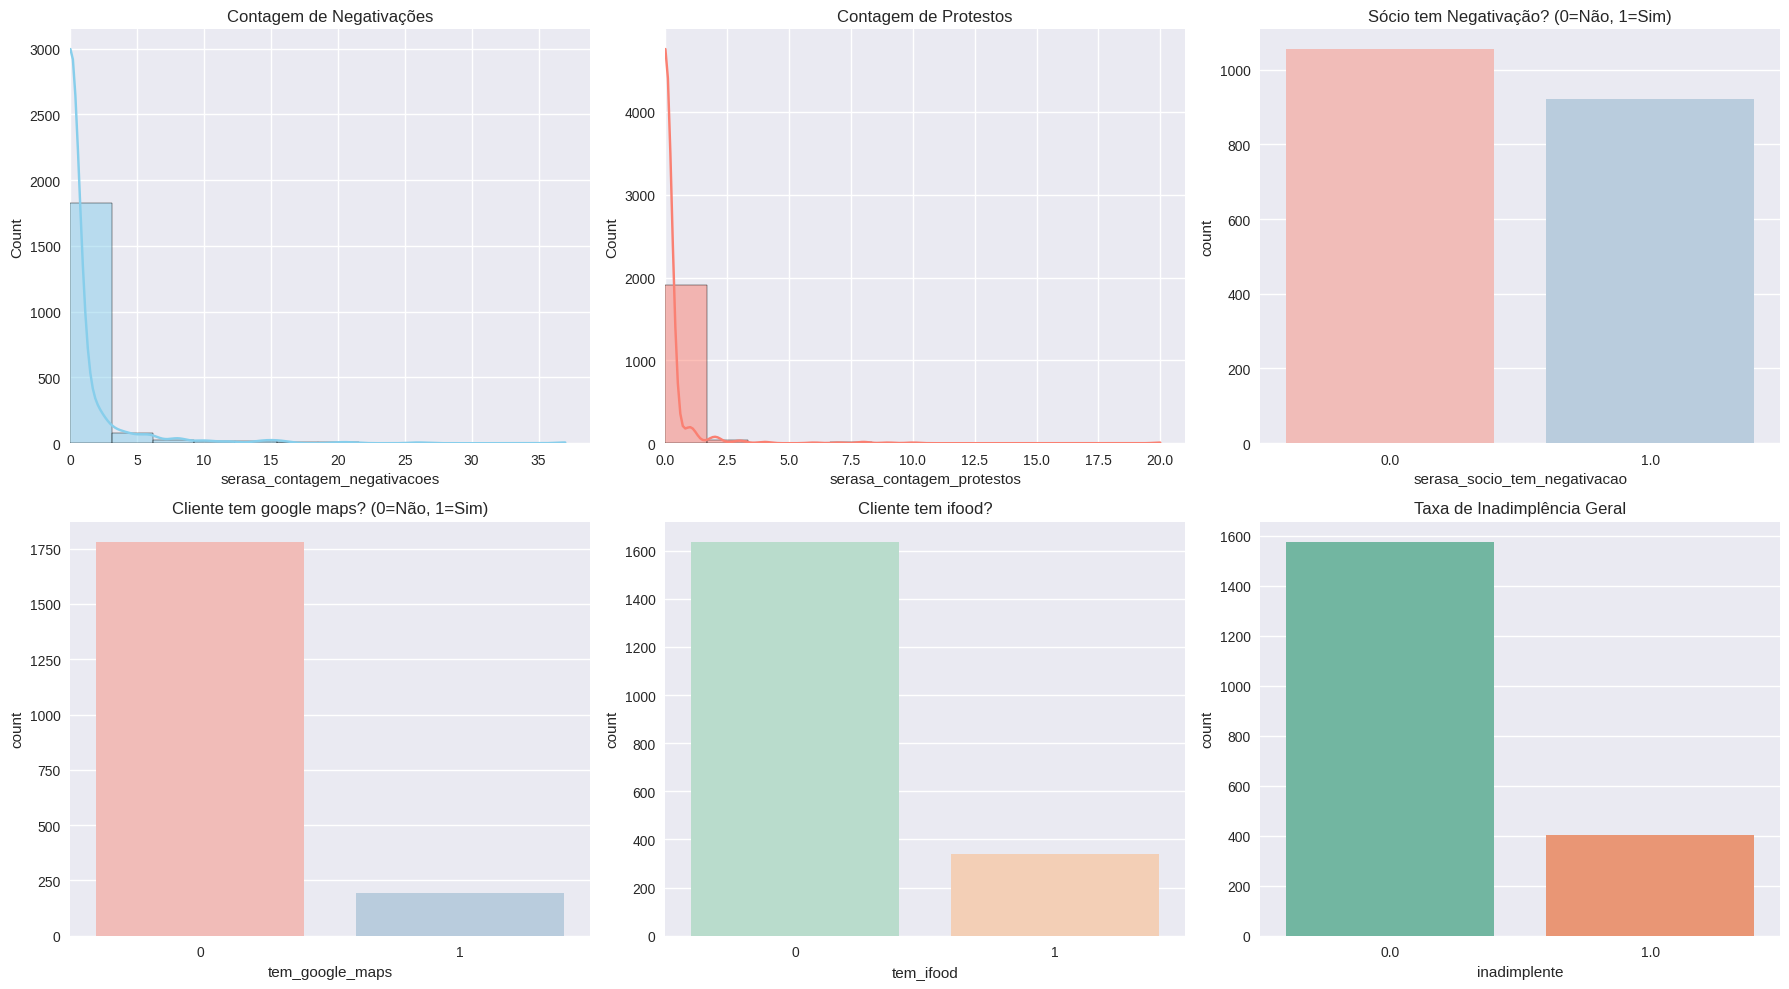

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Variáveis numéricas contínuas
sns.histplot(data=df3, x='serasa_contagem_negativacoes', ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Contagem de Negativações')
axes[0].set_xlim(left=0) #gráfico começa no zero

sns.histplot(data=df3, x='serasa_contagem_protestos', ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Contagem de Protestos')
axes[1].set_xlim(left=0) #gráfico começa no zero

# Variáveis binárias
sns.countplot(data=df3, x='serasa_socio_tem_negativacao', ax=axes[2], palette='Pastel1', hue='serasa_socio_tem_negativacao', legend=False)
axes[2].set_title('Sócio tem Negativação? (0=Não, 1=Sim)')

sns.countplot(data=df3, x='tem_google_maps', ax=axes[3], palette='Pastel1', hue='tem_google_maps', legend=False)
axes[3].set_title('Cliente tem google maps? (0=Não, 1=Sim)')

sns.countplot(data=df3, x='tem_ifood', ax=axes[4], palette='Pastel2', hue='tem_ifood', legend=False)
axes[4].set_title('Cliente tem ifood?')

# Target
sns.countplot(data=df3, x='inadimplente', ax=axes[5], palette='Set2', hue='inadimplente', legend=False)
axes[5].set_title('Taxa de Inadimplência Geral')

plt.tight_layout()
plt.show()

In [ ]:
#Outliers
for var in numericas_para_analise:
    if var in df3.columns:
        print(f"\n{var.upper()}:")
        data = df3[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


SERASA_CONTAGEM_NEGATIVACOES:
  Mean: 0.91
  Std: 3.03
  Skewness: 5.90
  Kurtosis: 46.67
  Outliers: 395 (20.0%)

SERASA_CONTAGEM_PROTESTOS:
  Mean: 0.20
  Std: 1.17
  Skewness: 10.56
  Kurtosis: 143.71
  Outliers: 143 (7.2%)


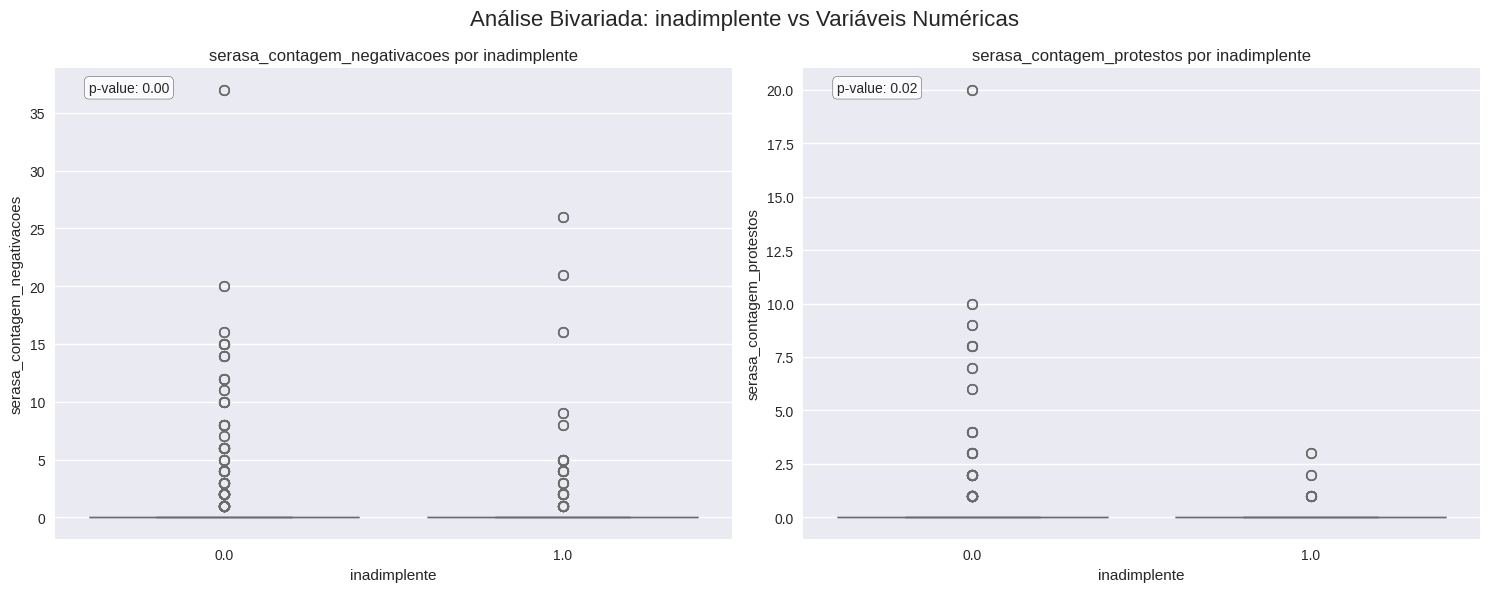

In [ ]:
# visualização outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Análise Bivariada: {target_var} vs Variáveis Numéricas', fontsize=16)
numeric_for_analysis = ['serasa_contagem_negativacoes', 'serasa_contagem_protestos']
for i, var in enumerate(numeric_for_analysis):
    if var in df.columns:
        col = i % 2

        # Box plot por categoria do target
        sns.boxplot(data=df3, x=target_var, y=var, ax=axes[col])
        axes[col].set_title(f'{var} por {target_var}')

        # Teste estatístico (t-test)
        group_0 = df[df[target_var] == 0][var].dropna()
        group_1 = df[df[target_var] == 1][var].dropna()

        if len(group_0) > 0 and len(group_1) > 0:
            t_stat, p_value = stats.ttest_ind(group_0, group_1)
            axes[col].text(0.05, 0.95, f'p-value: {p_value:.2f}',
                               transform=axes[col].transAxes,
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

# Análise Bivariada


## Categóricas e Intervalos

Análise Bivariada: inadimplente vs Variáveis Categóricas

TABELA DE CONTINGÊNCIA - municipio:
inadimplente              0.0  1.0
municipio                         
ACARAPE                     3    0
AQUIRAZ                    27    9
ARACATI                    30   15
ARACOIABA                   0    2
BARREIRA                    0    3
BATURITE                    3    0
BEBERIBE                   30    6
CASCAVEL                   15    6
CAUCAIA                   198   64
CHOROZINHO                  6    0
EUSEBIO                    50   15
FORTALEZA                1028  240
FORTIM                      6    0
GUAIUBA                     6    0
GUARAMIRANGA                6    3
HORIZONTE                  18    3
ITAICABA                    3    0
ITAITINGA                  15    9
MARACANAU                  54    3
MARANGUAPE                 12    2
PACAJUS                    30    9
PACATUBA                    9    3
PARACURU                    3    0
PINDORETAMA                12  

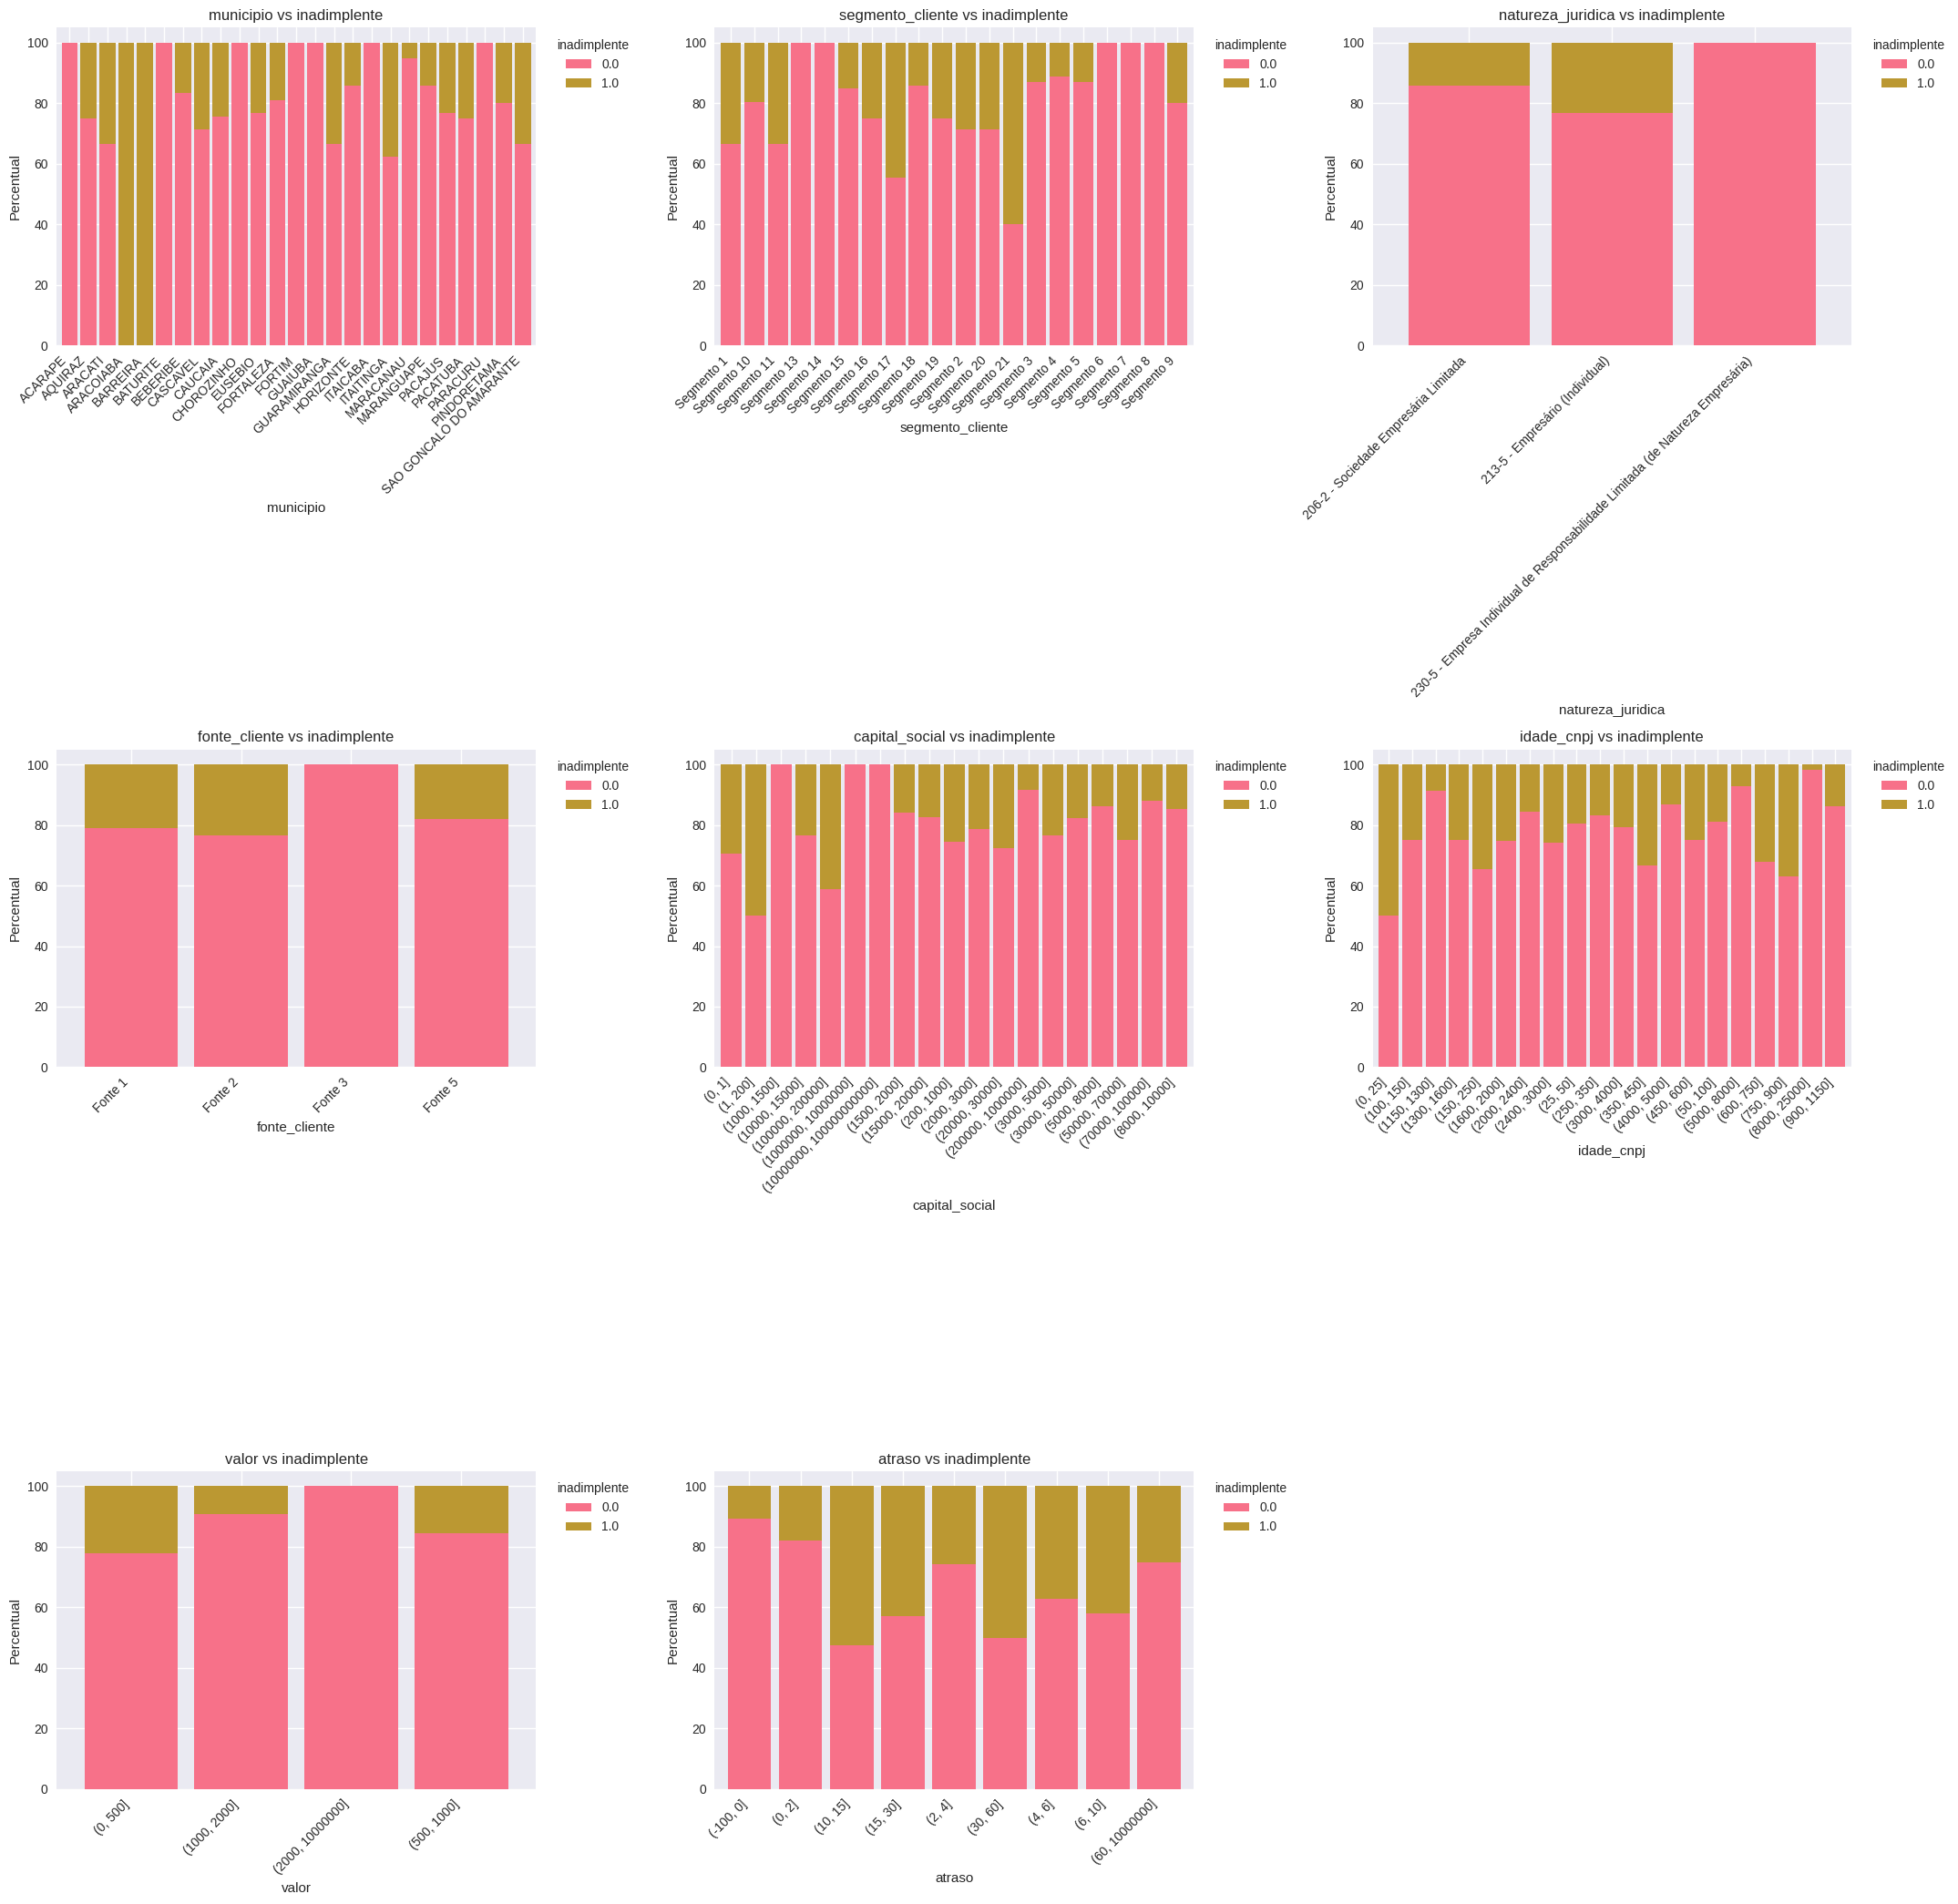

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Algumas categorias foram removidas por gerarem gráficos ilegíveis
categoricas_para_analise = [
  'municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'capital_social', 'idade_cnpj', 'valor', 'atraso'
]

num_vars_to_plot = len(categoricas_para_analise)

num_cols = 3
num_linhas = (num_vars_to_plot + num_cols - 1) // num_cols

fig, axes = plt.subplots(
    num_linhas,
    num_cols,
    figsize=(24, 7 * num_linhas)
)

axes = axes.flatten()

target_var = 'inadimplente'

print(f'Análise Bivariada: {target_var} vs Variáveis Categóricas')

plot_count = 0

for i, var in enumerate(categoricas_para_analise):


      # Tabela de contingência
      contingency_tabela = pd.crosstab(
          df3[var],
          df3[target_var]
      )

      print(f"\nTABELA DE CONTINGÊNCIA - {var}:")
      print(contingency_tabela)

      # Percentuais
      contingency_porcentagem = (
          pd.crosstab(
              df3[var],
              df3[target_var],
              normalize='index'
          ) * 100
      )

      print(f"\nPERCENTUAIS - {var}:")
      print(contingency_porcentagem.round(2))
      print("\n========================================")

      # Gráfico
      contingency_porcentagem.plot(
          kind='bar',
          stacked=True,
          ax=axes[plot_count],
          width=0.85
      )

      axes[plot_count].set_title(
          f'{var} vs {target_var}',
          fontsize=12
      )

      axes[plot_count].set_ylabel('Percentual')
      axes[plot_count].set_xlabel(var)

      # Legenda fora do gráfico
      axes[plot_count].legend(
          title=target_var,
          loc='upper left',
          bbox_to_anchor=(1.02, 1)
      )

      # Rótulos do eixo X
      axes[plot_count].set_xticklabels(
          contingency_porcentagem.index.astype(str),
          rotation=45,
          ha='right'
      )
      plot_count += 1

# Remove empty axes that were not used for plotting
for j in range(plot_count, len(axes)):
    fig.delaxes(axes[j])

# Ajusta espaço para legendas externas
plt.tight_layout(rect=[0, 0, 0.90, 1])

plt.show()

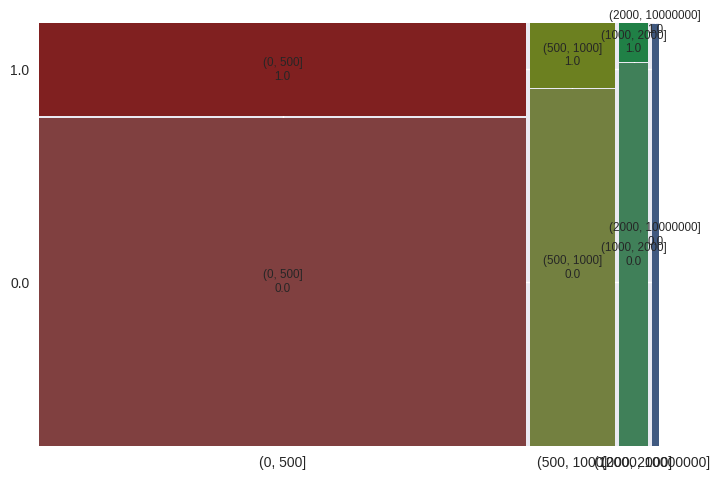

In [ ]:

mosaic(df3, ['valor','inadimplente'])
plt.show()

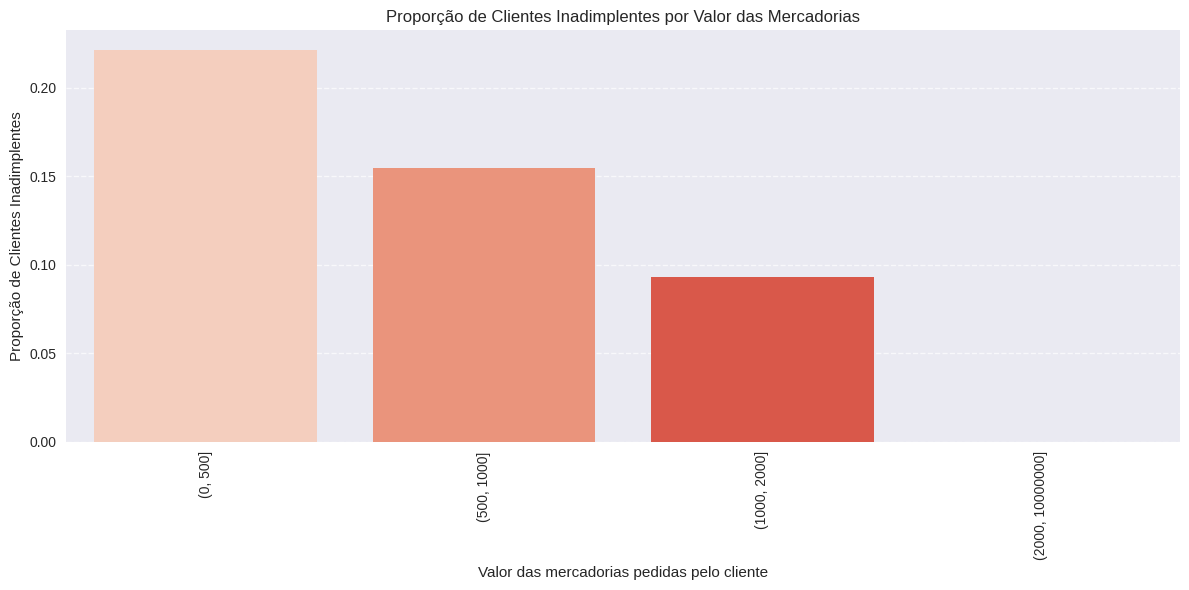

In [ ]:
idp_por_valor = df3.groupby('valor')['inadimplente'].mean()

def get_lower_bound(intervalo):
    return float(intervalo.replace('(', '').split(',')[0].strip())

idp_por_valor_sorted = idp_por_valor.copy()
idp_por_valor_sorted.index = idp_por_valor_sorted.index.map(str)

idp_por_valor_sorted = idp_por_valor_sorted.reindex(index=sorted(idp_por_valor_sorted.index, key=get_lower_bound))

# plot
plt.figure(figsize=(12, 6))
sns.barplot(x=idp_por_valor_sorted.index, y=idp_por_valor_sorted.values, palette='Reds')
plt.title('Proporção de Clientes Inadimplentes por Valor das Mercadorias')
plt.xlabel('Valor das mercadorias pedidas pelo cliente')
plt.ylabel('Proporção de Clientes Inadimplentes')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

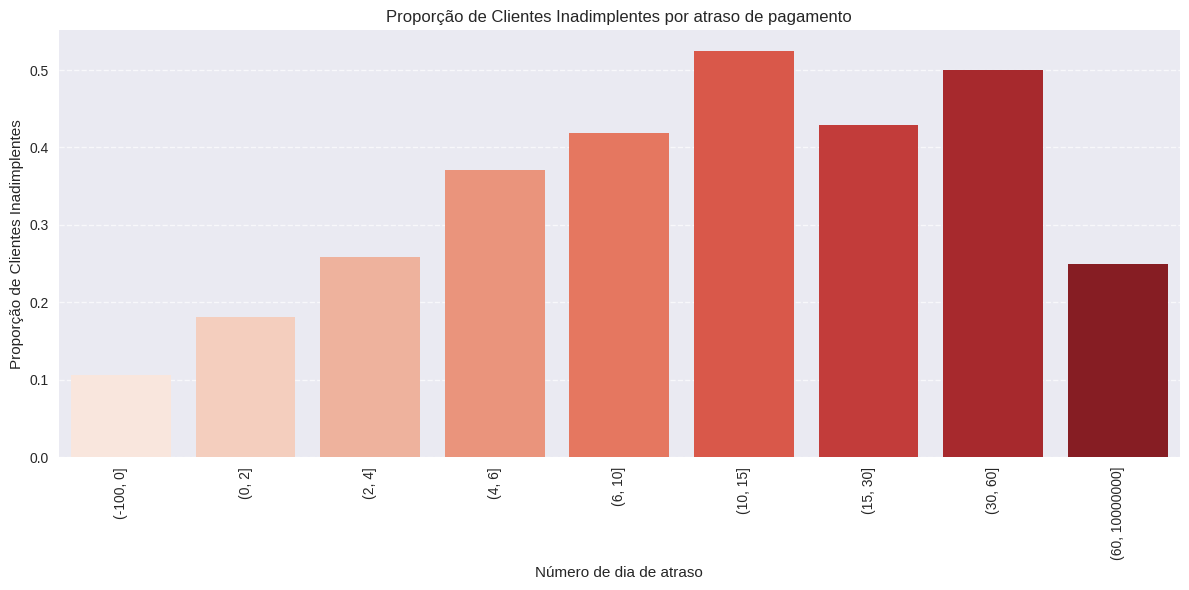

In [ ]:
# atraso VS inadimplente
idp_por_atraso = df3.groupby('atraso')['inadimplente'].mean()

idp_por_atraso_sorted = idp_por_atraso.copy()
idp_por_atraso_sorted.index = idp_por_atraso_sorted.index.map(str)

idp_por_atraso_sorted = idp_por_atraso_sorted.reindex(index=sorted(idp_por_atraso_sorted.index, key=get_lower_bound))

plt.figure(figsize=(12, 6))
sns.barplot(x=idp_por_atraso_sorted.index, y=idp_por_atraso_sorted.values, palette='Reds')
plt.title('Proporção de Clientes Inadimplentes por atraso de pagamento')
plt.xlabel('Número de dia de atraso')
plt.ylabel('Proporção de Clientes Inadimplentes')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Numéricas

Análise Bivariada: inadimplente vs Variáveis Categóricas

TABELA DE CONTINGÊNCIA - serasa_socio_tem_negativacao:
inadimplente                  0.0  1.0
serasa_socio_tem_negativacao          
0.0                           887  168
1.0                           689  233

PERCENTUAIS - serasa_socio_tem_negativacao:
inadimplente                    0.0    1.0
serasa_socio_tem_negativacao              
0.0                           84.08  15.92
1.0                           74.73  25.27


TABELA DE CONTINGÊNCIA - tem_google_maps:
inadimplente      0.0  1.0
tem_google_maps           
0                1402  380
1                 174   21

PERCENTUAIS - tem_google_maps:
inadimplente       0.0    1.0
tem_google_maps              
0                78.68  21.32
1                89.23  10.77


TABELA DE CONTINGÊNCIA - tem_ifood:
inadimplente   0.0  1.0
tem_ifood              
0             1277  361
1              299   40

PERCENTUAIS - tem_ifood:
inadimplente    0.0    1.0
tem_ifood              

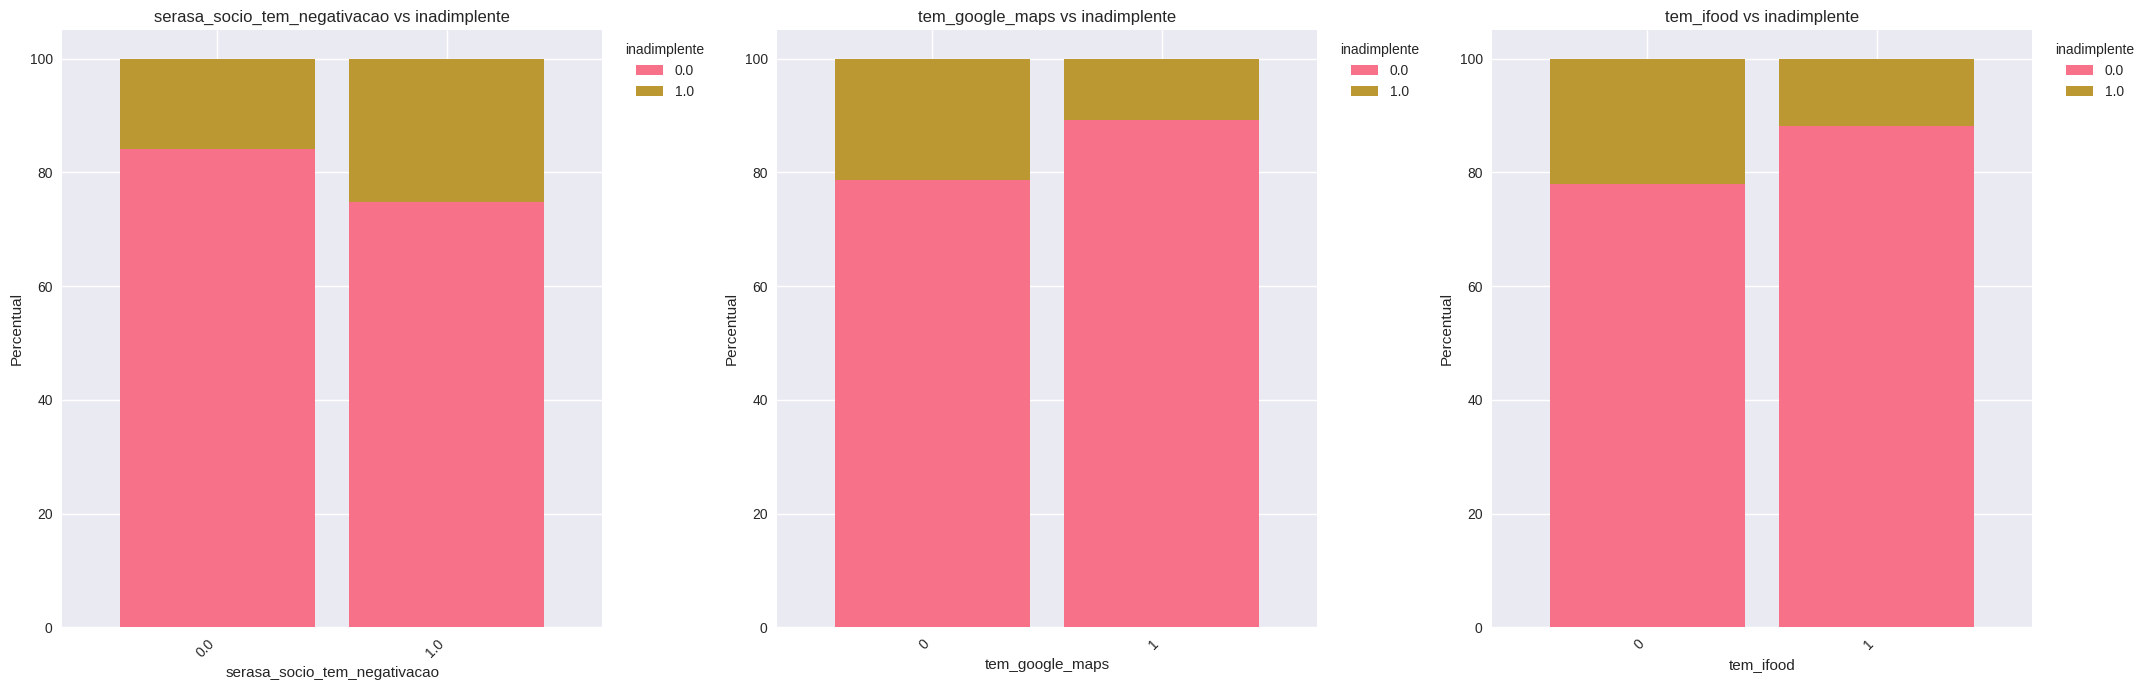

In [ ]:
binarias_para_analises = ["serasa_socio_tem_negativacao", "tem_google_maps", "tem_ifood"]
num_vars_to_plot = len(binarias_para_analises)

num_cols = 3
num_linhas = (num_vars_to_plot + num_cols - 1) // num_cols

fig, axes = plt.subplots(
    num_linhas,
    num_cols,
    figsize=(24, 7 * num_linhas)
)

axes = axes.flatten()

target_var = 'inadimplente'

print(f'Análise Bivariada: {target_var} vs Variáveis Categóricas')

plot_count = 0

for i, var in enumerate(binarias_para_analises):


      # Tabela de contingência
      contingency_tabela = pd.crosstab(
          df3[var],
          df3[target_var]
      )

      print(f"\nTABELA DE CONTINGÊNCIA - {var}:")
      print(contingency_tabela)

      # Percentuais
      contingency_porcentagem = (
          pd.crosstab(
              df3[var],
              df3[target_var],
              normalize='index'
          ) * 100
      )

      print(f"\nPERCENTUAIS - {var}:")
      print(contingency_porcentagem.round(2))
      print("\n========================================")

      # Gráfico
      contingency_porcentagem.plot(
          kind='bar',
          stacked=True,
          ax=axes[plot_count],
          width=0.85
      )

      axes[plot_count].set_title(
          f'{var} vs {target_var}',
          fontsize=12
      )

      axes[plot_count].set_ylabel('Percentual')
      axes[plot_count].set_xlabel(var)

      # Legenda fora do gráfico
      axes[plot_count].legend(
          title=target_var,
          loc='upper left',
          bbox_to_anchor=(1.02, 1)
      )

      # Rótulos do eixo X
      axes[plot_count].set_xticklabels(
          contingency_porcentagem.index.astype(str),
          rotation=45,
          ha='right'
      )
      plot_count += 1

# Remove empty axes that were not used for plotting
for j in range(plot_count, len(axes)):
    fig.delaxes(axes[j])

# Ajusta espaço para legendas externas
plt.tight_layout(rect=[0, 0, 0.90, 1])

plt.show()

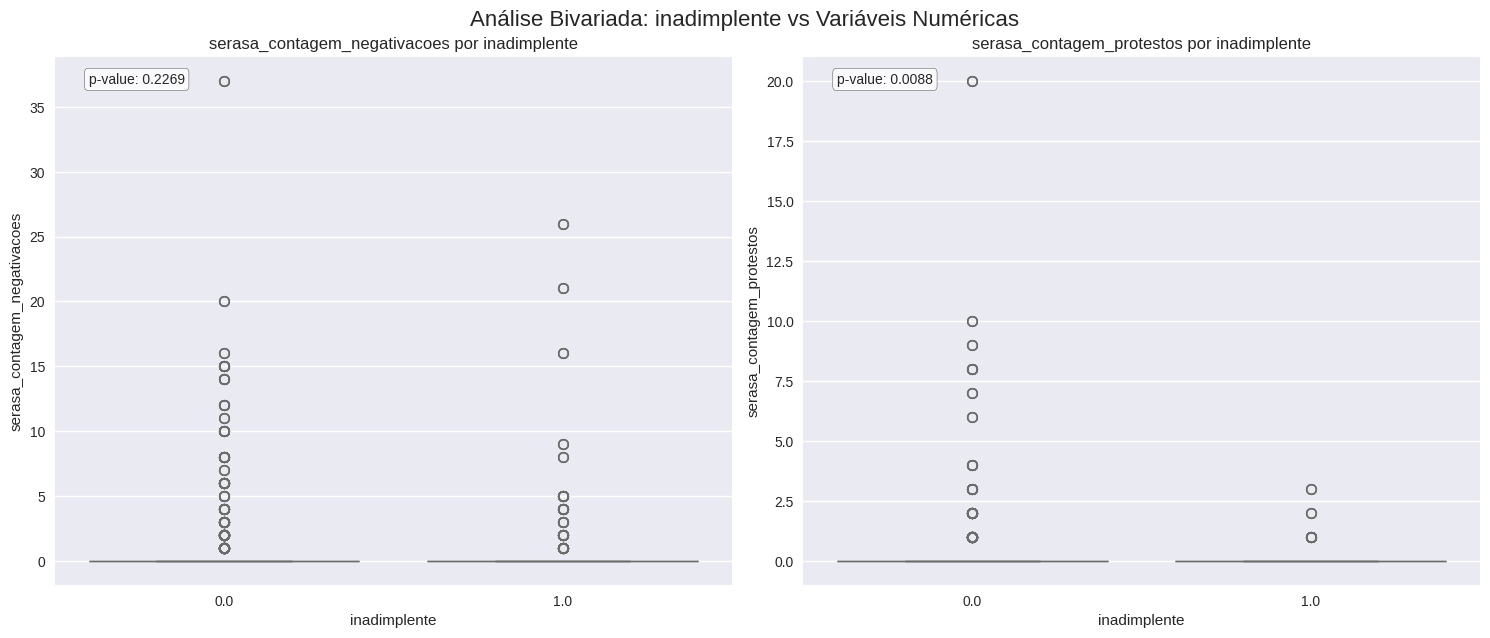

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Análise Bivariada: {target_var} vs Variáveis Numéricas', fontsize=16)

axes = axes.flatten()
plot_count = 0

for i, var in enumerate(numericas_para_analise):
    if var in df3.columns:

        # Box plot por categoria do target
        sns.boxplot(data=df3, x=target_var, y=var, ax=axes[plot_count])
        axes[plot_count].set_title(f'{var} por {target_var}')

        # Teste estatístico (t-test)
        group_0 = df3[df3[target_var] == 0][var].dropna()
        group_1 = df3[df3[target_var] == 1][var].dropna()

        if len(group_0) > 0 and len(group_1) > 0:
            t_stat, p_value = stats.ttest_ind(group_0, group_1)
            axes[plot_count].text(0.05, 0.95, f'p-value: {p_value:.4f}',
                               transform=axes[plot_count].transAxes,
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plot_count += 1

for j in range(plot_count, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Calcular matriz de correlação
correlation_matrix = df3[todos_numericos_analise].corr()

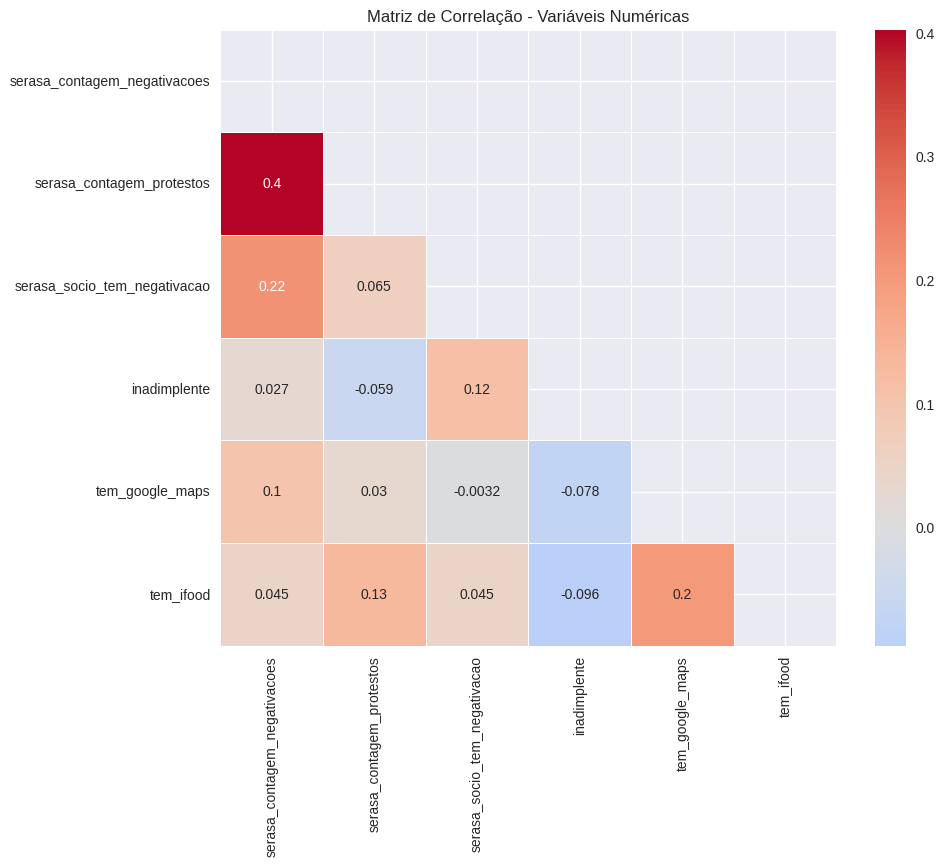

In [ ]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [ ]:
# Identificar correlações fortes
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:  # Correlação forte
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

In [ ]:
if strong_corr:
    print("\n CORRELAÇÕES FORTES (|r| > 0.4):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")


 CORRELAÇÕES FORTES (|r| > 0.4):
  serasa_contagem_negativacoes ↔ serasa_contagem_protestos: 0.402


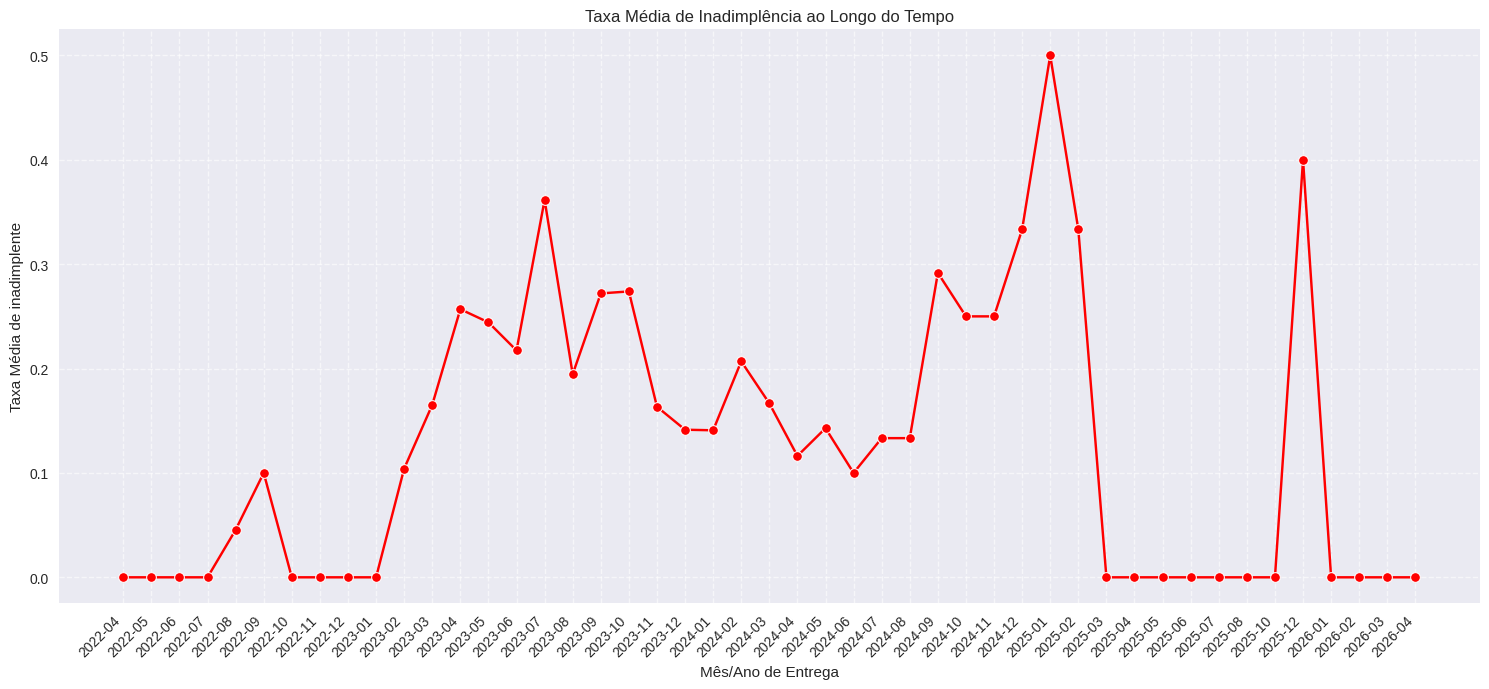

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_var = 'inadimplente'

# Convert 'data_entrega' to datetime (if not already done)
df3['data_entrega_dt'] = pd.to_datetime(df3['data_entrega'])

# Extract month and year for time series analysis
df3['year_month'] = df3['data_entrega_dt'].dt.to_period('M')

# Group by 'year_month' and calculate the mean 'inadimplente'
inad_over_time = df3.groupby('year_month')[target_var].mean().reset_index()

# Convert 'year_month' to string for consistent plotting
inad_over_time['year_month'] = inad_over_time['year_month'].astype(str)

# Plot the data
plt.figure(figsize=(15, 7))
sns.lineplot(data=inad_over_time, x='year_month', y=target_var, marker='o', color='red')
plt.title('Taxa Média de Inadimplência ao Longo do Tempo')
plt.xlabel('Mês/Ano de Entrega')
plt.ylabel(f'Taxa Média de {target_var}')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Clean up temporary columns from df3
df3 = df3.drop(columns=['data_entrega_dt', 'year_month'], errors='ignore')

# Análise Multivariada

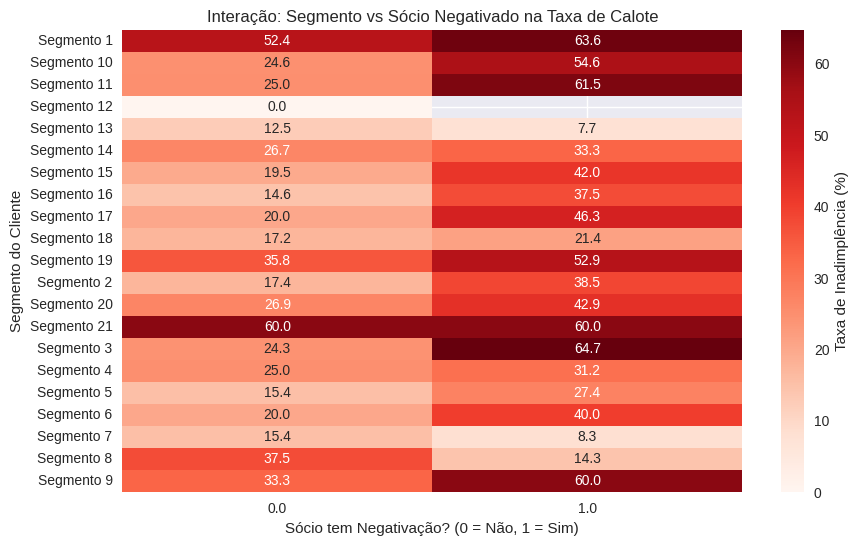

In [ ]:
#mapa de calor
mapa_risco = df.pivot_table(
    index= 'segmento_cliente',
    columns= 'serasa_socio_tem_negativacao',
    values= 'inadimplente',
    aggfunc= 'mean'
) * 100 #Para sair em porcentagem

plt.figure(figsize=(10,6))
sns.heatmap(mapa_risco, annot= True, fmt=".1f", cmap='Reds', cbar_kws={'label': 'Taxa de Inadimplência (%)'})
plt.title('Interação: Segmento vs Sócio Negativado na Taxa de Calote')
plt.xlabel('Sócio tem Negativação? (0 = Não, 1 = Sim)')
plt.ylabel('Segmento do Cliente')
plt.show()

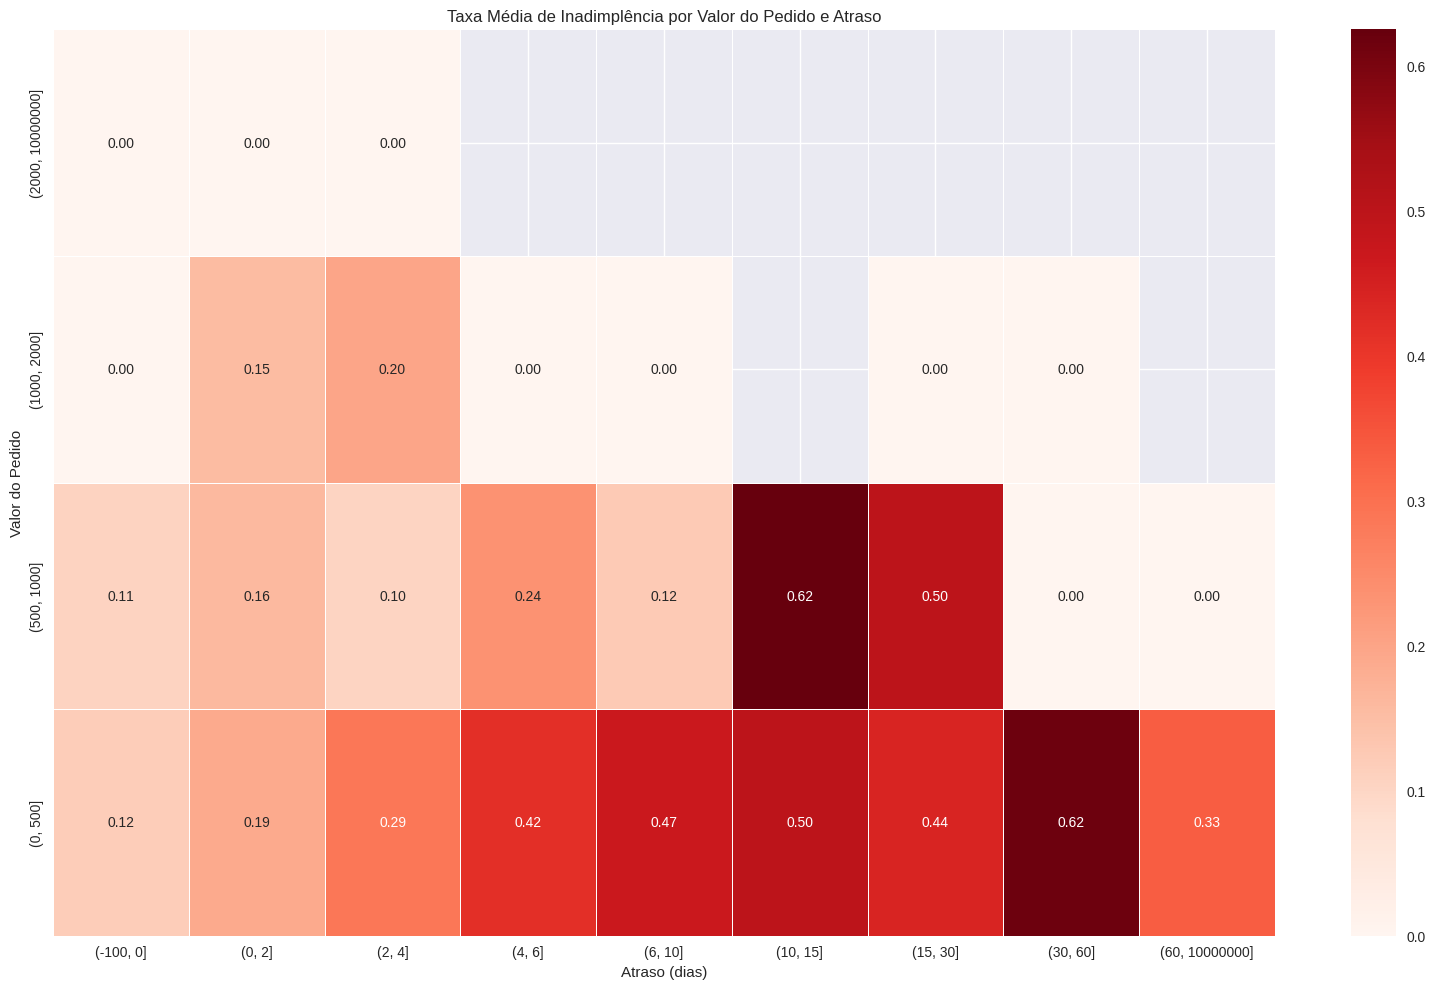

In [ ]:
valor_order = [ '(2000, 10000000]', '(1000, 2000]', '(500, 1000]' , '(0, 500]']
atraso_order = ['(-100, 0]', '(0, 2]', '(2, 4]', '(4, 6]', '(6, 10]', '(10, 15]', '(15, 30]', '(30, 60]', '(60, 10000000]']

df3['valor'] = pd.Categorical(df3['valor'], categories=valor_order, ordered=True)
df3['atraso'] = pd.Categorical(df3['atraso'], categories=atraso_order, ordered=True)

grouped_data = df3.groupby(['atraso', 'valor'])['inadimplente'].mean().reset_index()

pivot_table = grouped_data.pivot(index='valor', columns='atraso', values='inadimplente')

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='Reds', linewidths=.5)
plt.title('Taxa Média de Inadimplência por Valor do Pedido e Atraso')
plt.xlabel('Atraso (dias)')
plt.ylabel('Valor do Pedido')
plt.tight_layout()
plt.show()

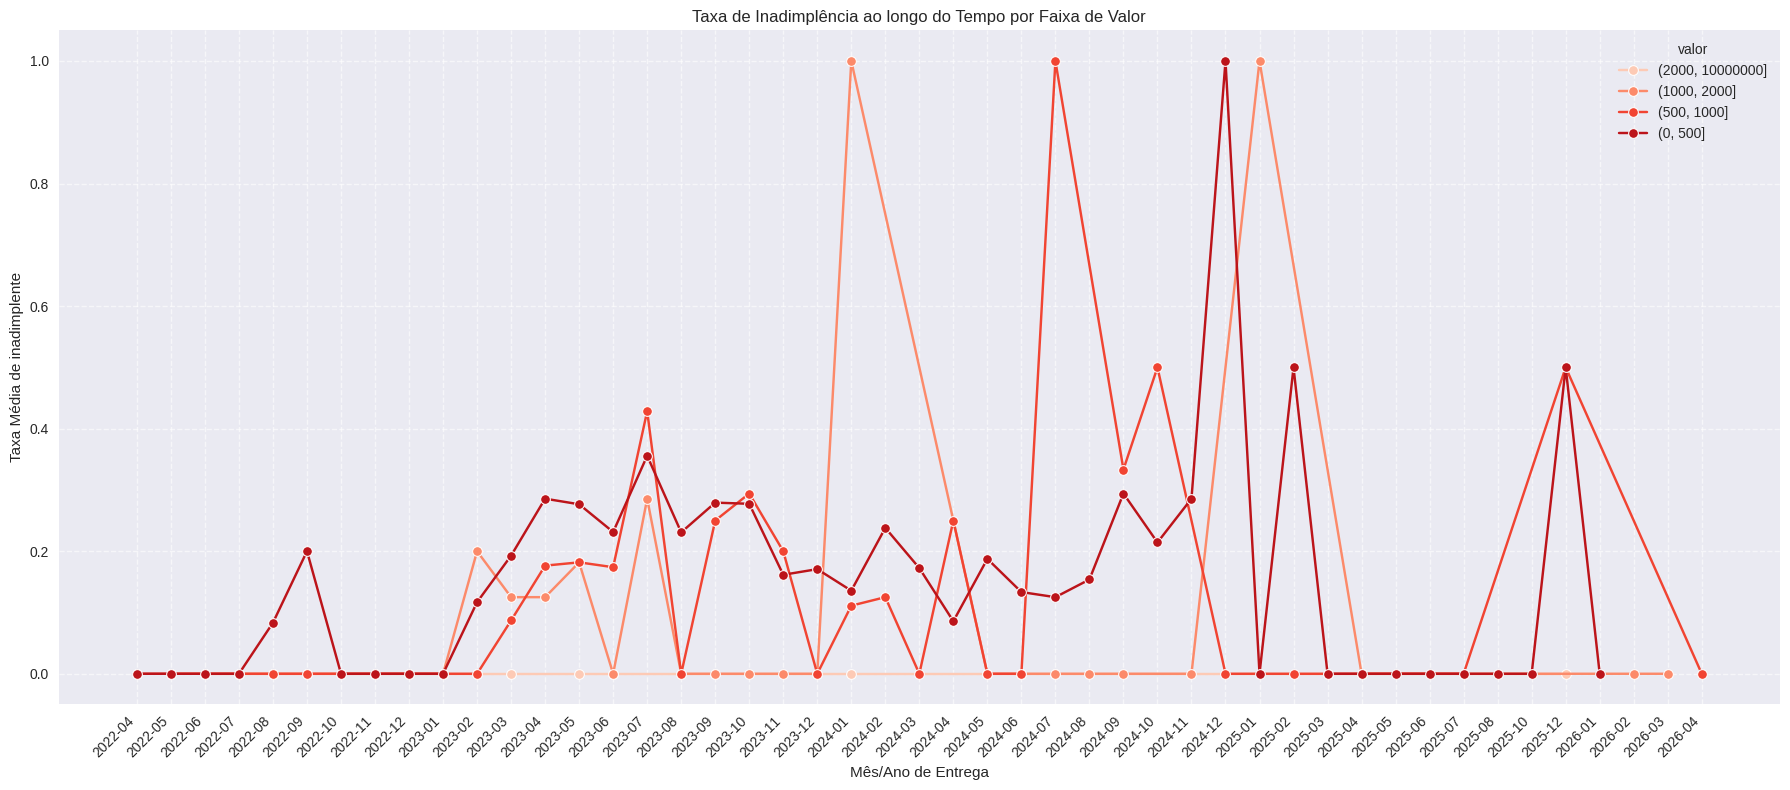

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_var = 'inadimplente'

# Convert 'data_entrega' to datetime
df3['data_entrega_dt'] = pd.to_datetime(df3['data_entrega'])

# Extract month and year for time series analysis
df3['year_month'] = df3['data_entrega_dt'].dt.to_period('M')

# Group by 'year_month' and 'valor', then calculate mean 'inadimplente'
inad_over_time_valor = df3.groupby(['year_month', 'valor'])[target_var].mean().reset_index()

# Convert 'year_month' to string for consistent plotting
inad_over_time_valor['year_month'] = inad_over_time_valor['year_month'].astype(str)

# Plot the data
plt.figure(figsize=(18, 8))
sns.lineplot(data=inad_over_time_valor, x='year_month', y=target_var, hue='valor', marker='o', palette='Reds')
plt.title('Taxa de Inadimplência ao longo do Tempo por Faixa de Valor')
plt.xlabel('Mês/Ano de Entrega')
plt.ylabel(f'Taxa Média de {target_var}')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Clean up temporary columns from df3
df3 = df3.drop(columns=['data_entrega_dt', 'year_month'], errors='ignore')

# Pré-Processamento

##Excluir unica linha nula

In [ ]:
df3 = df3.dropna()
print(df3.shape)

(1975, 20)


## Código CNAE - Tratamento

In [ ]:
df3['cnae_limpo'] = df3['cnae_codigo'].str.replace(r'[.\-]', '', regex=True)

#Cria as colunas categóricas baseadas na hierarquia
df3['cnae_divisao'] = df3['cnae_limpo'].str[:2]   # Pega os 2 primeiros caracteres
df3['cnae_grupo'] = df3['cnae_limpo'].str[:3]     # Pega os 3 primeiros caracteres
df3['cnae_classe'] = df3['cnae_limpo'].str[:5]    # Pega os 5 primeiros caracteres

print(df3[['cnae_codigo', 'cnae_divisao', 'cnae_grupo', 'cnae_classe']])

     cnae_codigo cnae_divisao cnae_grupo cnae_classe
3     77.74-5-45           77        777       77745
3     77.74-5-45           77        777       77745
3     77.74-5-45           77        777       77745
6     77.77-2-39           77        777       77772
6     77.77-2-39           77        777       77772
...          ...          ...        ...         ...
2993  77.12-9-14           77        771       77129
2993  77.12-9-14           77        771       77129
2999  53.23-6-24           53        532       53236
2999  53.23-6-24           53        532       53236
2999  53.23-6-24           53        532       53236

[1975 rows x 4 columns]


In [ ]:
contagem_divisoes = df3['cnae_divisao'].value_counts()
print(contagem_divisoes)

cnae_divisao
53    1050
77     537
39     272
74      21
25      14
76       9
12       9
97       9
23       6
64       6
78       6
29       6
30       3
88       3
33       3
86       3
93       3
36       3
26       3
16       3
34       3
79       3
Name: count, dtype: int64


In [ ]:
threshold = 200
divisoes_para_agrupar = contagem_divisoes[contagem_divisoes < threshold].index

df3["cnae_divisao_agrupado"] = np.where(
    df3["cnae_divisao"].isin(divisoes_para_agrupar),
    df3["cnae_divisao"],
    "Outros"
)


In [ ]:
df3["cnae_divisao_agrupado"] = np.where(
    df3["cnae_divisao"].isin(divisoes_para_agrupar),
    "Outros",
    df3["cnae_divisao"]
)
print(df3['cnae_divisao_agrupado'].value_counts())

cnae_divisao_agrupado
53        1050
77         537
39         272
Outros     116
Name: count, dtype: int64


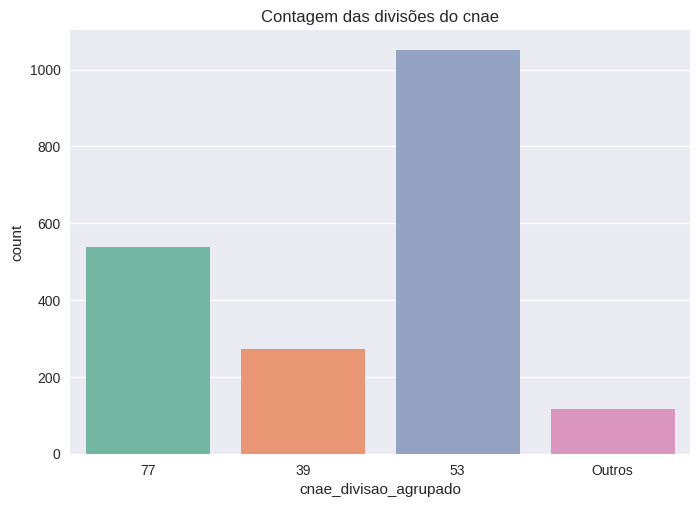

In [ ]:
sns.countplot(data=df3, x='cnae_divisao_agrupado', palette='Set2', hue='cnae_divisao_agrupado', legend=False)
plt.title('Contagem das divisões do cnae')
plt.show()

In [ ]:
contagem_grupos = df3['cnae_grupo'].value_counts()
print(contagem_grupos)

cnae_grupo
532    889
398    263
777    241
771    140
533    132
774     39
773     39
778     36
537     29
775     21
744     18
772     12
252     11
776      9
642      6
127      6
787      6
291      6
391      6
977      6
234      6
254      3
763      3
336      3
861      3
889      3
302      3
743      3
129      3
937      3
362      3
973      3
268      3
761      3
762      3
168      3
341      3
791      3
393      3
Name: count, dtype: int64


cnae_grupos_agrupado
532       889
Outros    310
398       263
777       241
771       140
533       132
Name: count, dtype: int64

O tipo da coluna agora é: object


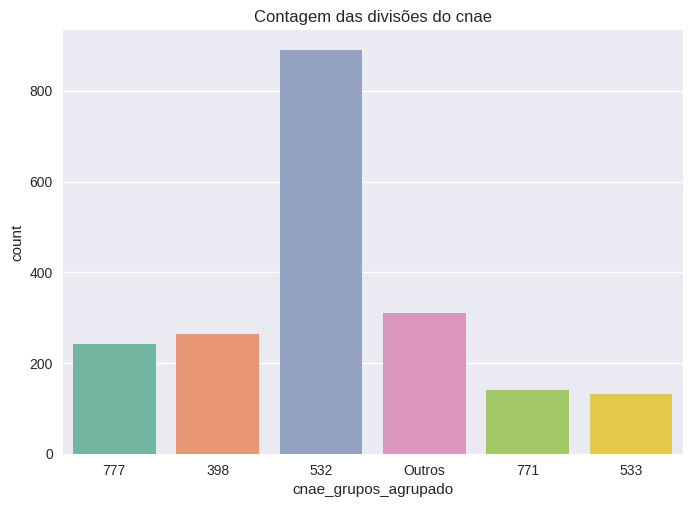

In [ ]:
contagem_grupos = df3['cnae_grupo'].value_counts()
threshold = 100
divisoes_para_grupos = contagem_grupos[contagem_grupos < threshold].index

df3["cnae_grupos_agrupado"] = np.where(
    df3["cnae_grupo"].isin(divisoes_para_grupos),
    "Outros",
    df3["cnae_grupo"]
).astype(object)

print(df3['cnae_grupos_agrupado'].value_counts())
print("\nO tipo da coluna agora é:", df3['cnae_grupos_agrupado'].dtype)

sns.countplot(data=df3, x='cnae_grupos_agrupado', palette='Set2', hue='cnae_grupos_agrupado', legend=False)
plt.title('Contagem das divisões do cnae')
plt.show()

In [ ]:
contagem_classes = df3['cnae_classe'].value_counts()
print(contagem_classes)

cnae_classe
53236    889
39876    263
77745    190
77129    140
53351    132
77772     42
77498     39
53772     29
74492     18
77599     18
77332     18
77365     15
77814     15
77896     15
25204     11
77608      9
77782      9
77281      9
77348      6
77882      6
12747      6
29142      6
23408      6
78782      6
39157      6
97786      6
64239      6
76342      3
74373      3
25458      3
30274      3
33641      3
86125      3
88908      3
77513      3
12942      3
93761      3
26871      3
36222      3
97308      3
77264      3
76284      3
76199      3
16814      3
34121      3
79183      3
39334      3
Name: count, dtype: int64


cnae_classes_agrupado
53236     889
Outros    361
39876     263
77745     190
77129     140
53351     132
Name: count, dtype: int64


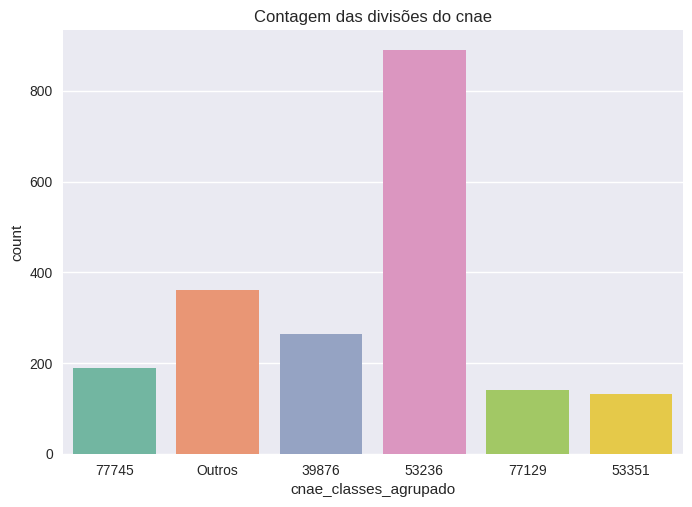

In [ ]:
contagem_classes = df3['cnae_classe'].value_counts() # Corrected 'cnae_classes' to 'cnae_classe'
threshold = 100
divisoes_para_agrupar_classes = contagem_classes[contagem_classes < threshold].index # Corrected variable usage and name

df3["cnae_classes_agrupado"] = np.where(
    df3["cnae_classe"].isin(divisoes_para_agrupar_classes), # Corrected 'cnae_classes' to 'cnae_classe' and used new variable
    "Outros",
    df3["cnae_classe"] # Corrected 'cnae_classes' to 'cnae_classe'
)
print(df3['cnae_classes_agrupado'].value_counts())

#gráfico
sns.countplot(data=df3, x='cnae_classes_agrupado', palette='Set2', hue='cnae_classes_agrupado', legend=False)
plt.title('Contagem das divisões do cnae')
plt.show()

In [ ]:
df3 = df3.drop(columns = ['cnae_classe','cnae_divisao','cnae_limpo','cnae_codigo','cnae_divisao_agrupado','cnae_classes_agrupado','cnae_grupos_agrupado'])

In [ ]:
df3 = df3.drop(columns={'uf', 'id_cliente', 'id_pedido'})

##Separação entre conjunto de teste e treino

Essa etapa é feita antes do encoding para evitar data leakeage

In [ ]:
X_aplicacao = df3.drop('inadimplente', axis=1)
y_aplicacao = df3['inadimplente']

#Estratificação garante que a proporção das classes seja mantida no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(
    X_aplicacao,
    y_aplicacao,
    test_size=0.2,
    stratify=y_aplicacao,
    random_state=42
)

##Encoding

In [ ]:
data_populacao_exemplo = {
    'municipio': [
        'FORTALEZA', 'CAUCAIA', 'MARACANAU', 'EUSEBIO', 'SOBRAL', 'JUAZEIRO DO NORTE',
        'ARACATI', 'HORIZONTE', 'AQUIRAZ', 'PACAJUS', 'PACATUBA', 'CASCAVEL',
        'BEBERIBE', 'MARANGUAPE', 'LIMOEIRO DO NORTE', 'SAO GONCALO DO AMARANTE',
        'ITAITINGA', 'REDENCAO', 'PINDORETAMA', 'GUAIUBA', 'FORTIM', 'ACARAPE',
        'ARACOIABA', 'BATURITE', 'BARREIRA', 'ICAPUI', 'SAO LUIS DO CURU', 'MAURITI',
        'SALITRE', 'JAGUARUANA', 'GUARAMIRANGA', 'CHOROZINHO', 'ITAICABA', 'PARACURU', 'ACARAU'
    ],
    'populacao': [
        2700000, 360000, 230000, 75000, 210000, 280000,
        70000, 65000, 80000, 60000, 90000, 70000,
        55000, 130000, 58000, 60000,
        40000, 30000, 20000, 25000, 15000, 16000,
        26000, 35000, 20000, 20000, 13000, 40000,
        17000, 38000, 4000, 20000, 20000, 35000, 60000
    ]
}

df_populacao = pd.DataFrame(data_populacao_exemplo)

pop_bins = [-np.inf, 50000, 500000, np.inf] # Limites das faixas: <50k, 50k-500k, >500k
pop_labels = [1, 2, 3] # 1=Baixa, 2=Média, 3=Alta

df_pop_temp = df_populacao.copy()

df_pop_temp['pop_encoded'] = pd.cut(
    df_pop_temp['populacao'],
    bins=pop_bins,
    labels=pop_labels,
    right=False,
    ordered=False
).astype(int)

municipio_pop_encoding = dict(zip(df_pop_temp['municipio'], df_pop_temp['pop_encoded']))

if 'municipio' not in X_train.columns:
    X_train = X_train.join(df3[['municipio']], how='left')
if 'municipio' not in X_test.columns:
    X_test = X_test.join(df3[['municipio']], how='left')


all_municipalities_in_data = pd.concat([X_train['municipio'], X_test['municipio']]).unique()

for mun in all_municipalities_in_data:
    if mun not in municipio_pop_encoding:
        municipio_pop_encoding[mun] = 0

print("Dicionário de encoding de município por faixa de População criado:")
display(municipio_pop_encoding)

X_train['municipio_pop_encoded'] = X_train['municipio'].map(municipio_pop_encoding)
X_test['municipio_pop_encoded'] = X_test['municipio'].map(municipio_pop_encoding)

X_train = X_train.drop('municipio', axis=1)
X_test = X_test.drop('municipio', axis=1)

print("\nEncoding de população aplicado na coluna 'municipio' para X_train e X_test.")
print(f"Novas dimensões de X_train: {X_train.shape}")
print(f"Novas dimensões de X_test: {X_test.shape}")
print("\nPrimeiras linhas de X_train com a nova coluna 'municipio_pop_encoded':")
display(X_train[['municipio_pop_encoded']].head())

Dicionário de encoding de município por faixa de População criado:


{'FORTALEZA': 3,
 'CAUCAIA': 2,
 'MARACANAU': 2,
 'EUSEBIO': 2,
 'SOBRAL': 2,
 'JUAZEIRO DO NORTE': 2,
 'ARACATI': 2,
 'HORIZONTE': 2,
 'AQUIRAZ': 2,
 'PACAJUS': 2,
 'PACATUBA': 2,
 'CASCAVEL': 2,
 'BEBERIBE': 2,
 'MARANGUAPE': 2,
 'LIMOEIRO DO NORTE': 2,
 'SAO GONCALO DO AMARANTE': 2,
 'ITAITINGA': 1,
 'REDENCAO': 1,
 'PINDORETAMA': 1,
 'GUAIUBA': 1,
 'FORTIM': 1,
 'ACARAPE': 1,
 'ARACOIABA': 1,
 'BATURITE': 1,
 'BARREIRA': 1,
 'ICAPUI': 1,
 'SAO LUIS DO CURU': 1,
 'MAURITI': 1,
 'SALITRE': 1,
 'JAGUARUANA': 1,
 'GUARAMIRANGA': 1,
 'CHOROZINHO': 1,
 'ITAICABA': 1,
 'PARACURU': 1,
 'ACARAU': 2}


Encoding de população aplicado na coluna 'municipio' para X_train e X_test.
Novas dimensões de X_train: (1580, 16)
Novas dimensões de X_test: (395, 16)

Primeiras linhas de X_train com a nova coluna 'municipio_pop_encoded':


,municipio_pop_encoded
2152,3
2658,3
1243,3
417,2
335,1


Como cada algoritimo precisa de um tratamento e encoding diferente, criamos copias do treino e teste para trata-los individualmente para cada algoritmo

In [ ]:
# Treino e teste da Regressão Logística
X_train_RegLog = X_train.copy()
X_test_RegLog = X_test.copy()

# Treino e teste da Random Forest
X_train_RandForest = X_train.copy()
X_test_RandForest = X_test.copy()

# Treino e teste do KNN
X_train_Knn = X_train.copy()
X_test_Knn = X_test.copy()

Primeiramente, algumas colunas, como capital_social, possuem intervalos ao invés de numeros, vamos transformar todos on intervalos em seus pontos médios, ex '[500, 1000)' em 750. Os algoritmos KNN e Regressão Logistica precisam disso para funcionar, enquanto a Random Forest se beneficia pois cria uma ordem numérica crescente, o que facilita a separação dos intervalos.

In [ ]:

def calculate_midpoint(interval_str):
    if pd.isna(interval_str):
        return interval_str

    vx, vy = str(interval_str).split(', ')

    vx = float(vx[1:])
    vy = float(vy[:-1])

    return (vx + vy) / 2

def apply_midpoints(df_train, df_test, columns):
    for col in columns:
        if col in df_train.columns:
            df_train[col] = df_train[col].apply(calculate_midpoint)
        if col in df_test.columns:
            df_test[col] = df_test[col].apply(calculate_midpoint)

    return df_train, df_test



In [ ]:
cols_intervalos = ['capital_social', 'idade_cnpj', 'ifood_contagem_avaliacoes', 'google_maps_contagem_avaliacoes', 'valor', 'atraso']

X_train_RandForest, X_test_RandForest = apply_midpoints(X_train_RandForest, X_test_RandForest, cols_intervalos)

X_train_RegLog, X_test_RegLog = apply_midpoints(X_train_RegLog, X_test_RegLog, cols_intervalos)

X_train_Knn, X_test_Knn = apply_midpoints(X_train_Knn, X_test_Knn, cols_intervalos)

Agora, temos o encoding de variaveis nominais. Esse encoding é mais especifico para cada algoritmo, já que fazendo um encoding numerico o KNN e a regreção logistica criam uma ideia de ordem

Random Forest:

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cols_nominais = [
    'segmento_cliente',
    'natureza_juridica',
    'fonte_cliente'
]

encoder_rf = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_RandForest[cols_nominais] = encoder_rf.fit_transform(X_train_RandForest[cols_nominais])
X_test_RandForest[cols_nominais] = encoder_rf.transform(X_test_RandForest[cols_nominais])

Para o KNN e reg Logistica, vamos usar um one hot, porem como algumas colunas tem muitos valores criamos uma função que pega os N valores mais comuns e transforam os demais valores na categoria 'outros'

In [ ]:
def encode_top_n_onehot(df_train, df_test, col, top_n=5):

    top_categories = df_train[col].value_counts().nlargest(top_n).index

    df_train[col] = df_train[col].where(df_train[col].isin(top_categories), 'Outros')
    df_test[col]  = df_test[col].where(df_test[col].isin(top_categories), 'Outros')

    train_dummies = pd.get_dummies(df_train[col], prefix=col, dtype=int)
    test_dummies  = pd.get_dummies(df_test[col], prefix=col, dtype=int)

    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    df_train = pd.concat([df_train, train_dummies], axis=1)
    df_test  = pd.concat([df_test, test_dummies], axis=1)

    df_train = df_train.drop(columns=[col])
    df_test  = df_test.drop(columns=[col])

    return df_train, df_test

In [ ]:
cols_nominais_top_n = [
    ('segmento_cliente', 7),
    ('natureza_juridica', 3),
    ('fonte_cliente', 4)
]

for col, n in cols_nominais_top_n:

    X_train_RegLog, X_test_RegLog = encode_top_n_onehot(
        X_train_RegLog,
        X_test_RegLog,
        col,
        top_n=n
    )

    X_train_Knn, X_test_Knn = encode_top_n_onehot(
        X_train_Knn,
        X_test_Knn,
        col,
        top_n=n
    )

In [ ]:
def encode_dates(df_train, df_test, date_col):
    df_train[date_col] = pd.to_datetime(df_train[date_col], errors='coerce')
    df_test[date_col]  = pd.to_datetime(df_test[date_col], errors='coerce')


    reference_date = df_train[date_col].min()

    df_train[f'{date_col}_dias_passados'] = (df_train[date_col] - reference_date).dt.days
    df_train[f'{date_col}_mes']           = df_train[date_col].dt.month
    df_train[f'{date_col}_dia_semana']    = df_train[date_col].dt.dayofweek # Monday=0, Sunday=6

    df_test[f'{date_col}_dias_passados'] = (df_test[date_col] - reference_date).dt.days
    df_test[f'{date_col}_mes']           = df_test[date_col].dt.month
    df_test[f'{date_col}_dia_semana']    = df_test[date_col].dt.dayofweek

    for new_col in [f'{date_col}_dias_passados', f'{date_col}_mes', f'{date_col}_dia_semana']:
        median_val = df_train[new_col].median()
        df_train[new_col] = df_train[new_col].fillna(median_val)
        df_test[new_col]  = df_test[new_col].fillna(median_val)

    df_train = df_train.drop(columns=[date_col])
    df_test  = df_test.drop(columns=[date_col])

    return df_train, df_test

In [ ]:
coluna_data = 'data_entrega'

X_train_RandForest, X_test_RandForest = encode_dates(X_train_RandForest, X_test_RandForest, coluna_data)
X_train_RegLog, X_test_RegLog = encode_dates(X_train_RegLog, X_test_RegLog, coluna_data)
X_train_Knn, X_test_Knn = encode_dates(X_train_Knn, X_test_Knn, coluna_data)

In [ ]:
def codificar_multilabel_top_n(df_train, df_test, coluna, top_n=10):
    df_train[coluna] = df_train[coluna].fillna('Desconhecido')
    df_test[coluna]  = df_test[coluna].fillna('Desconhecido')

    train_dummies = df_train[coluna].str.get_dummies(sep=', ')
    test_dummies  = df_test[coluna].str.get_dummies(sep=', ')

    top_tags = train_dummies.sum().nlargest(top_n).index.tolist()

    rare_cols_train = [c for c in train_dummies.columns if c not in top_tags]
    if rare_cols_train:
        train_dummies['Outros'] = (train_dummies[rare_cols_train].sum(axis=1) > 0).astype(int)
        train_dummies = train_dummies.drop(columns=rare_cols_train)
    else:
        train_dummies['Outros'] = 0

    rare_cols_test = [c for c in test_dummies.columns if c not in top_tags]
    if rare_cols_test:
        test_dummies['Outros'] = (test_dummies[rare_cols_test].sum(axis=1) > 0).astype(int)
        test_dummies = test_dummies.drop(columns=rare_cols_test)
    else:
        test_dummies['Outros'] = 0

    train_dummies = train_dummies.add_prefix(f'{coluna}_')
    test_dummies  = test_dummies.add_prefix(f'{coluna}_')


    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)


    df_train = pd.concat([df_train, train_dummies], axis=1)
    df_test  = pd.concat([df_test, test_dummies], axis=1)

    df_train = df_train.drop(columns=[coluna])
    df_test  = df_test.drop(columns=[coluna])

    return df_train, df_test

In [ ]:
coluna_setores = 'serasa_credores'
top_n_escolhido = 8

# 1. Random Forest
X_train_RandForest, X_test_RandForest = codificar_multilabel_top_n(
    X_train_RandForest, X_test_RandForest, coluna_setores, top_n=top_n_escolhido
)

# 2. Logistic Regression
X_train_RegLog, X_test_RegLog = codificar_multilabel_top_n(
    X_train_RegLog, X_test_RegLog, coluna_setores, top_n=top_n_escolhido
)

# 3. KNN
X_train_Knn, X_test_Knn = codificar_multilabel_top_n(
    X_train_Knn, X_test_Knn, coluna_setores, top_n=top_n_escolhido
)

##Normalização

In [ ]:
print(X_train_Knn.dtypes)

capital_social                                                                                         float64
idade_cnpj                                                                                             float64
serasa_contagem_negativacoes                                                                           float64
serasa_contagem_protestos                                                                              float64
serasa_socio_tem_negativacao                                                                           float64
valor                                                                                                 category
atraso                                                                                                category
tem_google_maps                                                                                          int64
tem_ifood                                                                                                int64
c

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler_knn = StandardScaler()
scaler_lr = StandardScaler()

#KNN
X_train_Knn_scaled = pd.DataFrame(
    scaler_knn.fit_transform(X_train_Knn),
    columns=X_train_Knn.columns,
    index=X_train_Knn.index
)


X_test_Knn_scaled = pd.DataFrame(
    scaler_knn.transform(X_test_Knn),
    columns=X_test_Knn.columns,
    index=X_test_Knn.index
)

# RegLog
X_train_RegLog_scaled = pd.DataFrame(
    scaler_lr.fit_transform(X_train_RegLog),
    columns=X_train_RegLog.columns,
    index=X_train_RegLog.index
)

X_test_RegLog_scaled = pd.DataFrame(
    scaler_lr.transform(X_test_RegLog),
    columns=X_test_RegLog.columns,
    index=X_test_RegLog.index
)

#PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
pca = PCA(n_components=0.90, random_state=42)

X_train_pca_reg_log = pca.fit_transform(X_train_RegLog_scaled)
X_test_pca_rec_log  = pca.transform(X_test_RegLog_scaled)

X_train_pca_knn = pca.fit_transform(X_train_Knn_scaled)
X_test_pca_knn  = pca.transform(X_test_Knn_scaled)

# Modelagem

# Regressão Logística

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca_reg_log, y_train)

y_pred_lr = lr.predict(X_test_pca_rec_log)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Logistic Regression: 0.7974683544303798


# Regressão Logística sem PCA

In [ ]:
colunas_continuas = ['capital_social']

pre_processador = ColumnTransformer(
    transformers=[
        ('kbins', KBinsDiscretizer(encode='onehot-dense', strategy='quantile'), colunas_continuas)
    ],
    remainder='passthrough'
)

lr_pipe_bins = Pipeline([
    ('pre_processador', pre_processador),
    ('balanceamento', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr_bins = {
    'pre_processador__kbins__n_bins': [3, 5, 8],

    'balanceamento': [SMOTE(random_state=42), RandomUnderSampler(random_state=42), 'passthrough'],

    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear']
}

grid_lr_bins = GridSearchCV(
    estimator=lr_pipe_bins,
    param_grid=param_grid_lr_bins,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)


print("Iniciando o tuning com KBinsDiscretizer")
grid_lr_bins.fit(X_train_RegLog, y_train)

modelo_lr_final = grid_lr_bins.best_estimator_

print("\nRESULTADO DO TUNING (LOGISTIC REGRESSION + BINS):")
print(f"Melhor configuração: {grid_lr_bins.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_lr_bins.best_score_:.4f}")

Iniciando o tuning com KBinsDiscretizer
Fitting 5 folds for each of 72 candidates, totalling 360 fits

RESULTADO DO TUNING (LOGISTIC REGRESSION + BINS):
Melhor configuração: {'balanceamento': SMOTE(random_state=42), 'lr__C': 10, 'lr__penalty': 'l1', 'lr__solver': 'liblinear', 'pre_processador__kbins__n_bins': 5}
Melhor AUC-ROC no Treino: 0.7103


In [ ]:
y_pred_lr_bins = modelo_lr_final.predict(X_test_RegLog)


precision_lr = precision_score(y_test, y_pred_lr_bins)
recall_lr = recall_score(y_test, y_pred_lr_bins)
f1_lr = f1_score(y_test, y_pred_lr_bins)



print("MÉTRICAS: REGRESSÃO LOGÍSTICA\n")
print(f"Precision (Precisão):     {precision_lr:.4f}")
print(f"Recall (Sensibilidade):   {recall_lr:.4f}")
print(f"F1-Score:                 {f1_lr:.4f}")

MÉTRICAS: REGRESSÃO LOGÍSTICA

Precision (Precisão):     0.3248
Recall (Sensibilidade):   0.6375
F1-Score:                 0.4304


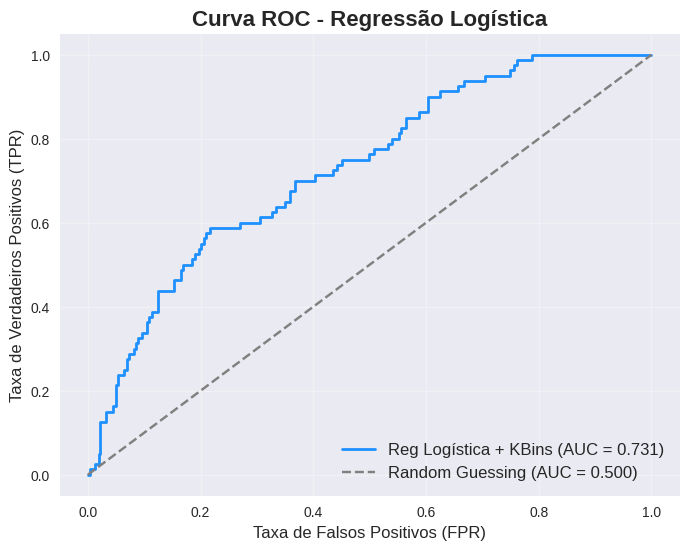

In [ ]:
prob_lr_bins = modelo_lr_final.predict_proba(X_test_RegLog)[:, 1]


auc_lr_bins = roc_auc_score(y_test, prob_lr_bins)
fpr_lr_bins, tpr_lr_bins, _ = roc_curve(y_test, prob_lr_bins)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr_bins, tpr_lr_bins, label=f'Reg Logística + KBins (AUC = {auc_lr_bins:.3f})', linewidth=2, color='dodgerblue')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - Regressão Logística', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# Random Forest

In [ ]:
#Não usa PCA
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_RandForest, y_train)

y_pred = rf.predict(X_test_RandForest)
print("Random Forest", accuracy_score(y_test, y_pred))

Random Forest 0.9189873417721519


In [ ]:
rf_pipe_dinamico = Pipeline([
    ('balanceamento', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True))
])

param_grid_rf_dinamico = {
    'balanceamento': [
        SMOTE(random_state=42),
        RandomUnderSampler(random_state=42),
        'passthrough'
    ],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 10],
    'rf__class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    estimator=rf_pipe_dinamico,
    param_grid=param_grid_rf_dinamico,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

print("Iniciando o treinamento")
grid_rf.fit(X_train_RandForest, y_train)

modelo_rf_otimizado = grid_rf.best_estimator_

print("RANDOM FOREST TUNING RESULTS:")
print(f"Melhor Configuração: {grid_rf.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_rf.best_score_:.4f}")

rf_vencedora = modelo_rf_otimizado.named_steps['rf']

oob_accuracy = rf_vencedora.oob_score_

oob_error = 1 - oob_accuracy

print("\nMÉTRICAS OUT-OF-BAG (OOB):")
print(f"OOB Score (Acurácia simulada): {oob_accuracy:.4f}")
print(f"OOB Error (Taxa de Erro):      {oob_error:.4f} (ou {oob_error * 100:.2f}%)")

Iniciando o treinamento
Fitting 5 folds for each of 72 candidates, totalling 360 fits
RANDOM FOREST TUNING RESULTS:
Melhor Configuração: {'balanceamento': 'passthrough', 'rf__class_weight': 'balanced', 'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Melhor AUC-ROC no Treino: 0.9338

MÉTRICAS OUT-OF-BAG (OOB):
OOB Score (Acurácia simulada): 0.8943
OOB Error (Taxa de Erro):      0.1057 (ou 10.57%)


In [ ]:
y_pred_rf = modelo_rf_otimizado.predict(X_test_RandForest)

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("MÉTRICAS DA RANDOM FOREST OTIMIZADA:")
print(f"Precision (Precisão):     {precision_rf:.4f}")
print(f"Recall (Sensibilidade):   {recall_rf:.4f}")
print(f"F1-Score:                 {f1_rf:.4f}")

MÉTRICAS DA RANDOM FOREST OTIMIZADA:
Precision (Precisão):     0.9787
Recall (Sensibilidade):   0.5750
F1-Score:                 0.7244


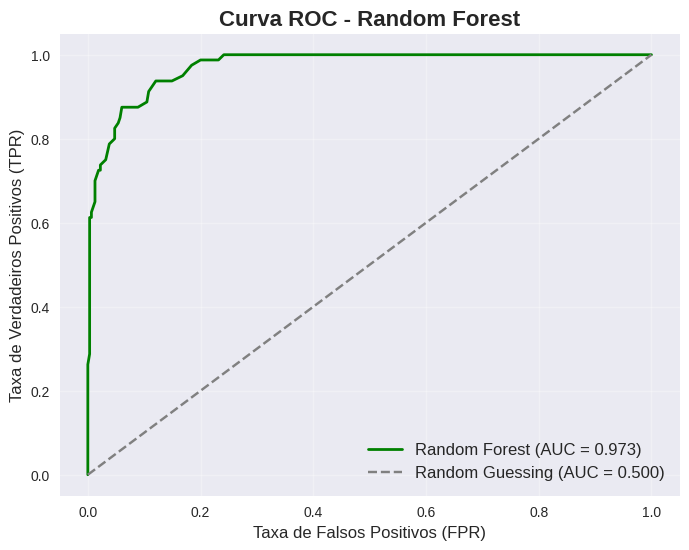

In [ ]:
prob_rf = modelo_rf_otimizado.predict_proba(X_test_RandForest)[:, 1]

auc_rf = roc_auc_score(y_test, prob_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2, color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## HistGradientBoosting (HGB)

In [ ]:
colunas_nominais = ['natureza_juridica', 'segmento_cliente', 'fonte_cliente']

for col in colunas_nominais:
    X_train_RandForest[col] = X_train_RandForest[col].astype('category')

    categorias_do_treino = X_train_RandForest[col].cat.categories
    X_test_RandForest[col] = X_test_RandForest[col].astype(pd.CategoricalDtype(categories=categorias_do_treino))



hgb_pipe = Pipeline([
    ('balanceamento', RandomUnderSampler(random_state=42)),
    ('hgb', HistGradientBoostingClassifier(
        categorical_features='from_dtype',
        random_state=42
    ))
])

param_grid_hgb = {
    'balanceamento': [RandomUnderSampler(random_state=42)],

    'hgb__learning_rate': [0.01, 0.05, 0.1],

    'hgb__max_iter': [100, 200, 300],

    'hgb__max_depth': [3, 5, None],

    'hgb__l2_regularization': [0.0, 1.0]
}

grid_hgb = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid_hgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

print("Iniciando o Tuning do HistGradientBoosting")
grid_hgb.fit(X_train_RandForest, y_train)

modelo_tree_avancado = grid_hgb.best_estimator_

print("\nRESULTADO DO TUNING DO HIST GRADIENT BOOSTING")
print(f"Melhor configuração: {grid_hgb.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_hgb.best_score_:.4f}")

Iniciando o Tuning do HistGradientBoosting
Fitting 5 folds for each of 54 candidates, totalling 270 fits

RESULTADO DO TUNING DO HIST GRADIENT BOOSTING
Melhor configuração: {'balanceamento': RandomUnderSampler(random_state=42), 'hgb__l2_regularization': 0.0, 'hgb__learning_rate': 0.1, 'hgb__max_depth': None, 'hgb__max_iter': 300}
Melhor AUC-ROC no Treino: 0.8522


In [ ]:
y_pred_tree = modelo_tree_avancado.predict(X_test_RandForest)

precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("MÉTRICAS: HIST GRADIENT BOOSTING (CATEGORIAS):")
print(f"Precision (Precisão):     {precision_tree:.4f}")
print(f"Recall (Sensibilidade):   {recall_tree:.4f}")
print(f"F1-Score:                 {f1_tree:.4f}")

MÉTRICAS: HIST GRADIENT BOOSTING (CATEGORIAS):
Precision (Precisão):     0.5139
Recall (Sensibilidade):   0.9250
F1-Score:                 0.6607


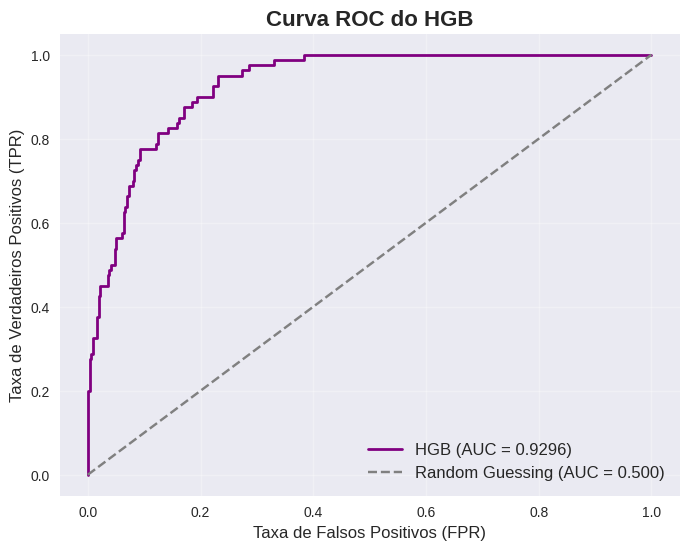

In [ ]:
prob_teste_real = modelo_tree_avancado.predict_proba(X_test_RandForest)[:, 1]
auc_teste_real = roc_auc_score(y_test, prob_teste_real)

fpr_real, tpr_real, _ = roc_curve(y_test, prob_teste_real)

plt.figure(figsize=(8, 6))
plt.plot(fpr_real, tpr_real, label=f'HGB (AUC = {auc_teste_real:.4f})', linewidth=2, color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC do HGB', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
resultado = permutation_importance(
    modelo_tree_avancado,
    X_test_RandForest,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

importancias = pd.DataFrame({
    'Variavel': X_test_RandForest.columns,
    'Importancia': resultado.importances_mean
}).sort_values(by='Importancia', ascending=False)

print("Top 5 Variáveis Mais Importantes para o Modelo:")
print(importancias.head(5))

Top 5 Variáveis Mais Importantes para o Modelo:
                      Variavel  Importancia
4                   idade_cnpj     0.129321
0             segmento_cliente     0.101063
3               capital_social     0.059706
14  data_entrega_dias_passados     0.055111
12                  cnae_grupo     0.030171


## HGB REGRESSOR

In [ ]:

hgb_pipe_reg = Pipeline([
    ('hgb', HistGradientBoostingRegressor(
        categorical_features='from_dtype',
        random_state=42
    ))
])

param_grid_hgb_reg = {
    'hgb__learning_rate': [0.01, 0.05, 0.1],
    'hgb__max_iter': [100, 200, 300],
    'hgb__max_depth': [3, 5, None],
    'hgb__l2_regularization': [0.0, 1.0]
}

grid_hgb_reg = GridSearchCV(
    estimator=hgb_pipe_reg,
    param_grid=param_grid_hgb_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

print("Iniciando o Tuning do HistGradientBoosting Regressor")
grid_hgb_reg.fit(X_train_RandForest, y_train)

modelo_hgb_reg_otimizado = grid_hgb_reg.best_estimator_

print("\nRESULTADO DO TUNING DO HGB REGRESSOR")
print(f"Melhor configuração: {grid_hgb_reg.best_params_}")
print(f"Melhor R² no Treino: {grid_hgb_reg.best_score_:.4f}")

Iniciando o Tuning do HistGradientBoosting Regressor
Fitting 5 folds for each of 54 candidates, totalling 270 fits

RESULTADO DO TUNING DO HGB REGRESSOR
Melhor configuração: {'hgb__l2_regularization': 0.0, 'hgb__learning_rate': 0.1, 'hgb__max_depth': None, 'hgb__max_iter': 300}
Melhor R² no Treino: 0.5623


MÉTRICAS: HIST GRADIENT BOOSTING REGRESSOR:
MAE (Erro Absoluto Médio):       0.1440
RMSE (Erro Quadrático Médio):    0.2111
R-quadrado (R²):                 0.7241


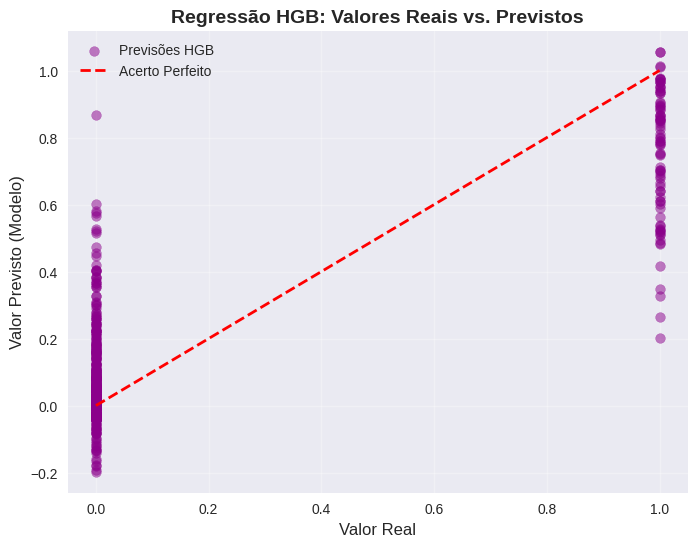

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_hgb_reg = modelo_hgb_reg_otimizado.predict(X_test_RandForest)

mae_hgb = mean_absolute_error(y_test, y_pred_hgb_reg)
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb_reg))
r2_hgb = r2_score(y_test, y_pred_hgb_reg)

print("MÉTRICAS: HIST GRADIENT BOOSTING REGRESSOR:")
print(f"MAE (Erro Absoluto Médio):       {mae_hgb:.4f}")
print(f"RMSE (Erro Quadrático Médio):    {rmse_hgb:.4f}")
print(f"R-quadrado (R²):                 {r2_hgb:.4f}")


plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_hgb_reg, alpha=0.5, color='darkmagenta', label='Previsões HGB')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2, label='Acerto Perfeito')

plt.title('Regressão HGB: Valores Reais vs. Previstos', fontsize=14, fontweight='bold')
plt.xlabel('Valor Real', fontsize=12)
plt.ylabel('Valor Previsto (Modelo)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

## XGBOOST

In [ ]:
colunas_para_limpar = X_train_RandForest.select_dtypes(include=['object', 'category']).columns

for col in colunas_para_limpar:
    X_train_RandForest[col] = X_train_RandForest[col].astype(str).astype('category')

    categorias_treino = X_train_RandForest[col].cat.categories

    X_test_RandForest[col] = pd.Categorical(
        X_test_RandForest[col].astype(str),
        categories=categorias_treino
    )

xgb_pipe = Pipeline([
    ('xgb', XGBClassifier(...))
])

In [ ]:

xgb_pipe = Pipeline([
    ('balanceamento', RandomUnderSampler(random_state=42)),
    ('xgb', XGBClassifier(
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        eval_metric='auc',
        n_jobs=-1
    ))
])

param_grid_xgb = {
    'balanceamento': [RandomUnderSampler(random_state=42), 'passthrough'],

    'xgb__n_estimators': [100, 200],

    'xgb__max_depth': [3, 5],

    'xgb__learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning rápido do XGBoost")
grid_xgb.fit(X_train_RandForest, y_train)

modelo_xgb_otimizado = grid_xgb.best_estimator_

print("\nRESULTADO DO TUNING DO XGBOOST ")
print(f"Melhor configuração: {grid_xgb.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_xgb.best_score_:.4f}")

Iniciando o tuning rápido do XGBoost
Fitting 5 folds for each of 16 candidates, totalling 80 fits

RESULTADO DO TUNING DO XGBOOST 
Melhor configuração: {'balanceamento': 'passthrough', 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}
Melhor AUC-ROC no Treino: 0.9251


In [ ]:

y_pred_xgb = modelo_xgb_otimizado.predict(X_test_RandForest)

precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("MÉTRICAS: XGBOOST OTIMIZADO")
print(f"Precision (Precisão):     {precision_xgb:.4f}")
print(f"Recall (Sensibilidade):   {recall_xgb:.4f}")
print(f"F1-Score:                 {f1_xgb:.4f}")

MÉTRICAS: XGBOOST OTIMIZADO
Precision (Precisão):     0.9062
Recall (Sensibilidade):   0.7250
F1-Score:                 0.8056


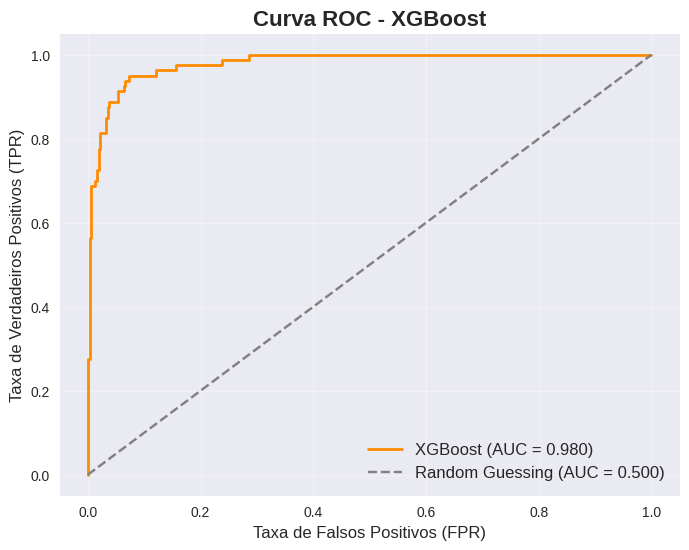

In [ ]:

prob_xgb = modelo_xgb_otimizado.predict_proba(X_test_RandForest)[:, 1]

auc_xgb = roc_auc_score(y_test, prob_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2, color='darkorange')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - XGBoost', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
#REGRESSÃO
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb_pipe_reg = Pipeline([
    ('xgb', XGBRegressor(
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        eval_metric='rmse',
        n_jobs=-1
    ))
])

param_grid_xgb_reg = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.05, 0.1]
}

grid_xgb_reg = GridSearchCV(
    estimator=xgb_pipe_reg,
    param_grid=param_grid_xgb_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning rápido do XGBoost Regressor")
grid_xgb_reg.fit(X_train_RandForest, y_train)

modelo_xgb_reg_otimizado = grid_xgb_reg.best_estimator_

print("\nRESULTADO DO TUNING DO XGBOOST REGRESSOR")
print(f"Melhor configuração: {grid_xgb_reg.best_params_}")
print(f"Melhor R² no Treino (Cross-Validation): {grid_xgb_reg.best_score_:.4f}")

Iniciando o tuning rápido do XGBoost Regressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits

RESULTADO DO TUNING DO XGBOOST REGRESSOR
Melhor configuração: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}
Melhor R² no Treino (Cross-Validation): 0.5114


In [ ]:

y_pred_xgb = modelo_xgb_otimizado.predict(X_test_RandForest)

precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("MÉTRICAS: XGBOOST OTIMIZADO")
print(f"Precision (Precisão):     {precision_xgb:.4f}")
print(f"Recall (Sensibilidade):   {recall_xgb:.4f}")
print(f"F1-Score:                 {f1_xgb:.4f}")

MÉTRICAS: XGBOOST OTIMIZADO
Precision (Precisão):     0.9062
Recall (Sensibilidade):   0.7250
F1-Score:                 0.8056


# KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca_knn, y_train)

y_pred_knn = knn.predict(X_test_pca_knn)
print("KNN:", accuracy_score(y_test, y_pred_knn))

KNN: 0.8075949367088607


In [ ]:
# estava tendo um conflito com o Pipeline do sklearn
from imblearn.pipeline import Pipeline as ImbPipeline

knn_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning do KNN Classificador...")
grid_knn.fit(X_train_Knn_scaled, y_train)


modelo_knn_clf_otimizado = grid_knn.best_estimator_
print(f"\nMelhores Parâmetros: {grid_knn.best_params_}")


y_pred_knn = modelo_knn_clf_otimizado.predict(X_test_Knn_scaled)
prob_knn = modelo_knn_clf_otimizado.predict_proba(X_test_Knn_scaled)[:, 1]

print("\n--- Resultados no Teste ---")
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN AUC-ROC:  {roc_auc_score(y_test, prob_knn):.4f}")

Iniciando o tuning do KNN Classificador...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores Parâmetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}

--- Resultados no Teste ---
KNN Accuracy: 0.8633
KNN AUC-ROC:  0.9461


In [ ]:

y_pred_knn = modelo_knn_clf_otimizado.predict(X_test_Knn_scaled)

precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print("MÉTRICAS DO KNN OTIMIZADO")
print(f"Precision (Precisão):     {precision:.4f}")
print(f"Recall (Sensibilidade):   {recall:.4f}")
print(f"F1-Score:                 {f1:.4f}")

MÉTRICAS DO KNN OTIMIZADO
Precision (Precisão):     0.6204
Recall (Sensibilidade):   0.8375
F1-Score:                 0.7128


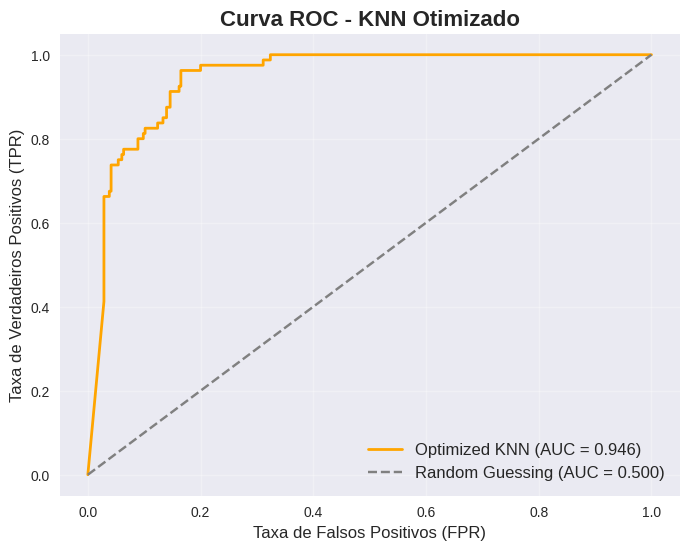

In [ ]:

prob_knn = modelo_knn_clf_otimizado.predict_proba(X_test_Knn_scaled)[:, 1]

auc_knn = roc_auc_score(y_test, prob_knn)
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)

plt.figure(figsize=(8, 6))

plt.plot(fpr_knn, tpr_knn, label=f'Optimized KNN (AUC = {auc_knn:.3f})', linewidth=2, color='orange')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - KNN Otimizado', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:

knn_pipe = Pipeline([
    ('knn', KNeighborsRegressor())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Iniciando o tuning do KNN Regressor...")
grid_knn.fit(X_train_Knn_scaled, y_train)

modelo_knn_otimizado = grid_knn.best_estimator_
print(f"\nMelhores Parâmetros: {grid_knn.best_params_}")

y_pred_knn = modelo_knn_otimizado.predict(X_test_Knn_scaled)

mae = mean_absolute_error(y_test, y_pred_knn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2 = r2_score(y_test, y_pred_knn)

print("\n--- Resultados no Teste (Regressão) ---")
print(f"MAE (Erro Médio Absoluto):  {mae:.4f}")
print(f"RMSE (Erro Quadrático Médio): {rmse:.4f}")
print(f"R-quadrado (R²):            {r2:.4f}")

Iniciando o tuning do KNN Regressor...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores Parâmetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}

--- Resultados no Teste (Regressão) ---
MAE (Erro Médio Absoluto):  0.1362
RMSE (Erro Quadrático Médio): 0.2642
R-quadrado (R²):            0.5678


# SVC

In [ ]:
# estava tendo um conflito com o Pipeline do sklearn
from imblearn.pipeline import Pipeline as ImbPipeline

svc_pipe = ImbPipeline([
    ('balanceamento', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
])

param_grid_svc = {
    'balanceamento': [SMOTE(random_state=42), RandomUnderSampler(random_state=42)],
    'svc__C': [0.1, 1, 10, 50],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(
    estimator=svc_pipe,
    param_grid=param_grid_svc,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=3
)

print("Iniciando o tuning COMPLETO do SVC")
grid_svc.fit(X_train_RegLog_scaled, y_train)

modelo_svc_otimizado = grid_svc.best_estimator_

print("\n=== RESULTADO DO TUNING DO SVC ===")
print(f"Melhor configuração: {grid_svc.best_params_}")
print(f"Melhor AUC-ROC no Treino: {grid_svc.best_score_:.4f}")

Iniciando o tuning COMPLETO do SVC
Fitting 5 folds for each of 32 candidates, totalling 160 fits

=== RESULTADO DO TUNING DO SVC ===
Melhor configuração: {'balanceamento': SMOTE(random_state=42), 'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Melhor AUC-ROC no Treino: 0.8661


In [ ]:

# 1. Previsões rígidas (0 ou 1)
y_pred_svc = modelo_svc_otimizado.predict(X_test_RegLog_scaled)

# 2. Cálculos
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)


print("MÉTRICAS: SUPPORT VECTOR CLASSIFIER (SVC):")
print(f"Precision (Precisão):     {precision_svc:.4f}")
print(f"Recall (Sensibilidade):   {recall_svc:.4f}")
print(f"F1-Score:                 {f1_svc:.4f}")

MÉTRICAS: SUPPORT VECTOR CLASSIFIER (SVC):
Precision (Precisão):     0.6634
Recall (Sensibilidade):   0.8375
F1-Score:                 0.7403


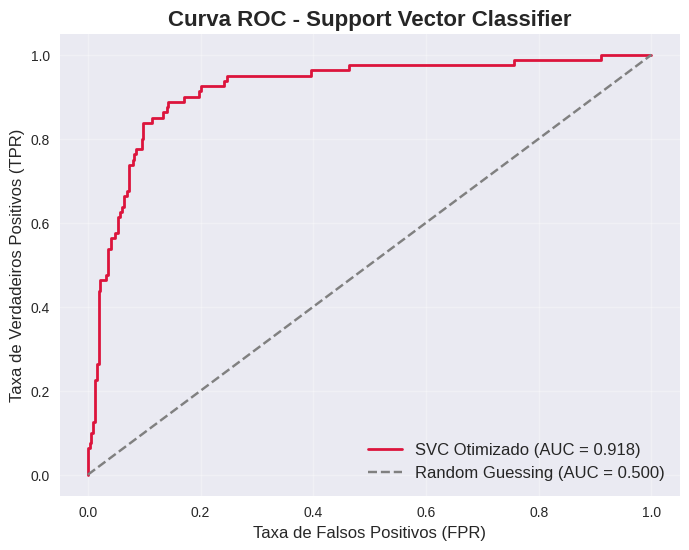

In [ ]:

# 1. Probabilidade de ser Inadimplente
prob_svc = modelo_svc_otimizado.predict_proba(X_test_RegLog_scaled)[:, 1]

# 2. Coordenadas e AUC
auc_svc = roc_auc_score(y_test, prob_svc)
fpr_svc, tpr_svc, _ = roc_curve(y_test, prob_svc)

# 3. Gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr_svc, tpr_svc, label=f'SVC Otimizado (AUC = {auc_svc:.3f})', linewidth=2, color='crimson')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.500)')

plt.title('Curva ROC - Support Vector Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Análise e comparação de resultados

### Regressão

Calculando métricas comparativas

Comparação Modelos de Regressão:


,Modelo,R²,RMSE,MAE
0,XGBoost Regressor,0.673047,0.229798,0.155573
1,KNN Regressor,0.567751,0.264223,0.136232
2,HistGradientBoosting,0.341272,0.326179,0.260578


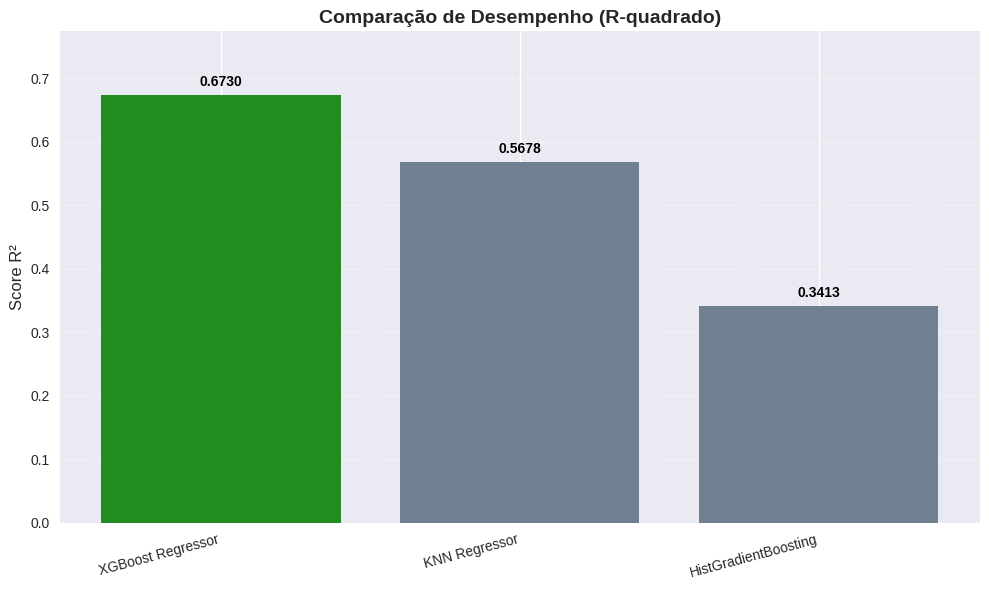

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


modelos_regressao = {
    'XGBoost Regressor': (modelo_xgb_reg_otimizado, X_test_RandForest),
    'HistGradientBoosting': (modelo_hgb_reg_otimizado, X_test_RandForest),
    'KNN Regressor': (modelo_knn_otimizado, X_test_Knn_scaled)

}

resultados_regressao = []

print("Calculando métricas comparativas\n")


for nome, (modelo, x_teste) in modelos_regressao.items():
    try:
        y_pred = modelo.predict(x_teste)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        resultados_regressao.append({
            'Modelo': nome,
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae
        })
    except NameError:
        print(f"Aviso: O modelo '{nome}' não foi encontrado na memória. Ele foi ignorado no gráfico.")
    except Exception as e:
         print(f"Erro ao avaliar '{nome}': {e}")

df_comparativo_reg = pd.DataFrame(resultados_regressao)

if not df_comparativo_reg.empty:
    df_comparativo_reg = df_comparativo_reg.sort_values(by='R²', ascending=False).reset_index(drop=True)

    print("Comparação Modelos de Regressão:")
    display(df_comparativo_reg)

    plt.figure(figsize=(10, 6))

    cores = ['forestgreen'] + ['slategray'] * (len(df_comparativo_reg) - 1)

    barras = plt.bar(df_comparativo_reg['Modelo'], df_comparativo_reg['R²'], color=cores)

    plt.title('Comparação de Desempenho (R-quadrado)', fontsize=14, fontweight='bold')
    plt.ylabel('Score R²', fontsize=12)
    plt.xticks(rotation=15, ha='right')

    plt.ylim(0, max(df_comparativo_reg['R²']) * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f'{altura:.4f}',
            ha='center',
            va='bottom',
            fontweight='bold',
            color='black'
        )

    plt.tight_layout()
    plt.show()
else:
    print("Nenhum modelo estava disponível na memória para gerar o comparativo.")

### Classificação

A calcular métricas comparativas de classificação

Comparação modelos de classificação


,Modelo,AUC-ROC,Accuracy,Precision,Recall,F1-Score
0,XGBoost Classifier,0.979524,0.929114,0.906250,0.7250,0.805556
1,Random Forest,0.972659,0.911392,0.978723,0.5750,0.724409
2,KNN Classifier,0.946131,0.863291,0.620370,0.8375,0.712766
3,SVC (Support Vector),0.918492,0.881013,0.663366,0.8375,0.740331
4,HistGradientBoosting,0.801190,0.711392,0.383562,0.7000,0.495575
5,Regressão Logística,0.730516,0.658228,0.324841,0.6375,0.430380


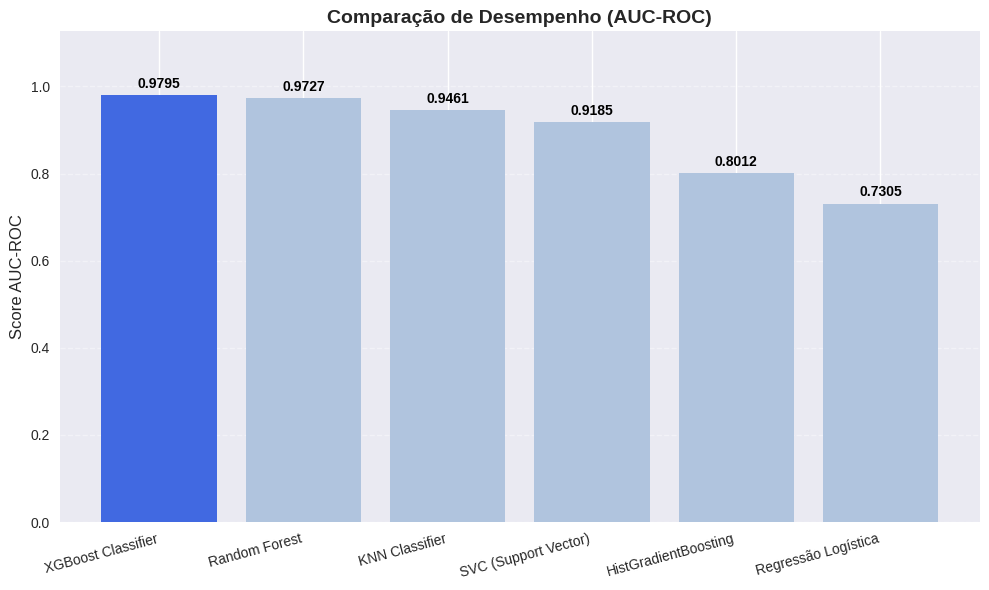

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

modelos_classificacao = {
    'XGBoost Classifier': (modelo_xgb_otimizado, X_test_RandForest),
    'HistGradientBoosting': (modelo_tree_avancado, X_test_RandForest),
    'Random Forest': (modelo_rf_otimizado, X_test_RandForest),
    'Regressão Logística': (modelo_lr_final, X_test_RegLog),
    'KNN Classifier': (modelo_knn_clf_otimizado, X_test_Knn_scaled),
    'SVC (Support Vector)': (modelo_svc_otimizado, X_test_RegLog_scaled)
}

resultados_classificacao = []

print("A calcular métricas comparativas de classificação\n")


for nome, (modelo, x_teste) in modelos_classificacao.items():
    try:
        y_pred = modelo.predict(x_teste)

        y_pred_prob = modelo.predict_proba(x_teste)[:, 1]

        auc = roc_auc_score(y_test, y_pred_prob)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        resultados_classificacao.append({
            'Modelo': nome,
            'AUC-ROC': auc,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })
    except NameError:
        print(f"Aviso: O modelo '{nome}' não foi encontrado na memória. Foi ignorado no gráfico.")
    except Exception as e:
         print(f"Erro ao avaliar '{nome}': {e}")

df_comparativo_clf = pd.DataFrame(resultados_classificacao)

if not df_comparativo_clf.empty:
    df_comparativo_clf = df_comparativo_clf.sort_values(by='AUC-ROC', ascending=False).reset_index(drop=True)

    print("Comparação modelos de classificação")
    display(df_comparativo_clf)

    plt.figure(figsize=(10, 6))

    cores = ['royalblue'] + ['lightsteelblue'] * (len(df_comparativo_clf) - 1)

    barras = plt.bar(df_comparativo_clf['Modelo'], df_comparativo_clf['AUC-ROC'], color=cores)

    plt.title('Comparação de Desempenho (AUC-ROC)', fontsize=14, fontweight='bold')
    plt.ylabel('Score AUC-ROC', fontsize=12)
    plt.xticks(rotation=15, ha='right')

    plt.ylim(0, max(df_comparativo_clf['AUC-ROC']) * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f'{altura:.4f}',
            ha='center',
            va='bottom',
            fontweight='bold',
            color='black'
        )

    plt.tight_layout()
    plt.show()
else:
    print("Nenhum modelo estava disponível na memória para gerar o comparativo.")